In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings, os, pickle, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets, load_psd_results, aggregate_population,
    run_population_tests, run_fraction_sig_tests, run_r2_tests,
    plot_population_results, plot_r2_distributions, plot_beta_distributions,
    build_population_scatter, save_population_results,
    compare_hpf_versions, show_beta_tables, plot_target_correlations,
    plot_r2_summary,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

In [2]:
# ── Run-control flags ───────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


# Population ridge regression — spe-1

Pool single-cell ridge regression results (n=39 cells) and test whether spike waveform features systematically predict pre/post-spike LFP state.

| § | What |
|---|------|
| 1 | Load per-cell result pickles |
| 2 | Aggregate R², significance flags, and beta weights |
| 3 | Population tests: R² > 0 (primary), fraction significant (binomial), beta consistency |
| 4 | Visualisations: R² and beta heatmaps, per-cell R² distributions, beta distributions |
| 5 | Actual vs predicted scatter (pooled, z-scored within cell) |
| 6 | Save population pickle |
| 7 | HPF vs no-HPF comparison for amp/std targets |

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
ALPHA            = 0.05   # significance threshold (each test assessed independently)
MIN_CELLS        = 5

## Configuration

`PRE_WIN` / `POST_WIN`: time windows (s) around the spike for LFP feature extraction.  
`ALPHA`: significance threshold (default 0.05). Each target is tested independently — no correction across targets.  
`MIN_CELLS`: minimum cells required to run a population test.

**LFP targets (14 total)**  
Pre and Post absolute windows × 5 LFP features. LFP Amp and LFP Std appear as both raw and HPF (0.1 Hz zero-phase Butterworth) variants. Baseline-corrected variants are excluded — HPF handles detrending.

**Statistical approach**  
Each LFP target = a distinct scientific question, tested independently at α = 0.05. No correction across targets.

In [4]:
# ── 1. Load — merge HPF amp/std as named targets, drop BL-corrected and Δ ──────
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

Merged: 39 cells  |  14 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)


In [5]:
# ── 1b. Load single-PSD results ──────────────────────────────────────────────
(all_results_psd, cell_ids_psd,
 target_names_psd, target_labels_psd,
 predictor_sets_psd) = load_psd_results(RIDGE_PICKLE_DIR, FEAT_LABELS)

PSD: 42 cells  |  10 targets (Pre+Post abs, single-PSD method, theta=4–15 Hz, slow_gamma=30–60 Hz, high_gamma=60–80 Hz)


## 1. Load per-cell results

14 targets: Pre and Post windows for each of the 5 LFP features. LFP Amp and LFP Std appear twice — once using raw LFP windows and once with 0.1 Hz HPF detrending. Baseline-corrected and Δ variants are excluded (HPF handles detrending for amp/std; gamma/exponent/theta are unaffected by slow drift).

In [6]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

In [7]:
# ── 2b-psd. Aggregate single-PSD R², significance, and betas ─────────────────
r2_pop_psd, sig_pop_psd, beta_pop_psd = aggregate_population(
    all_results_psd, cell_ids_psd, target_names_psd, predictor_sets_psd,
)

## 2. Aggregate across cells

`r2_pop`   — CV R² per cell per (target × predictor set)  
`sig_pop`  — per-cell significance flags (raw permutation p < 0.05, each target independent)  
`beta_pop` — waveform beta weights (Waveform only model) per cell

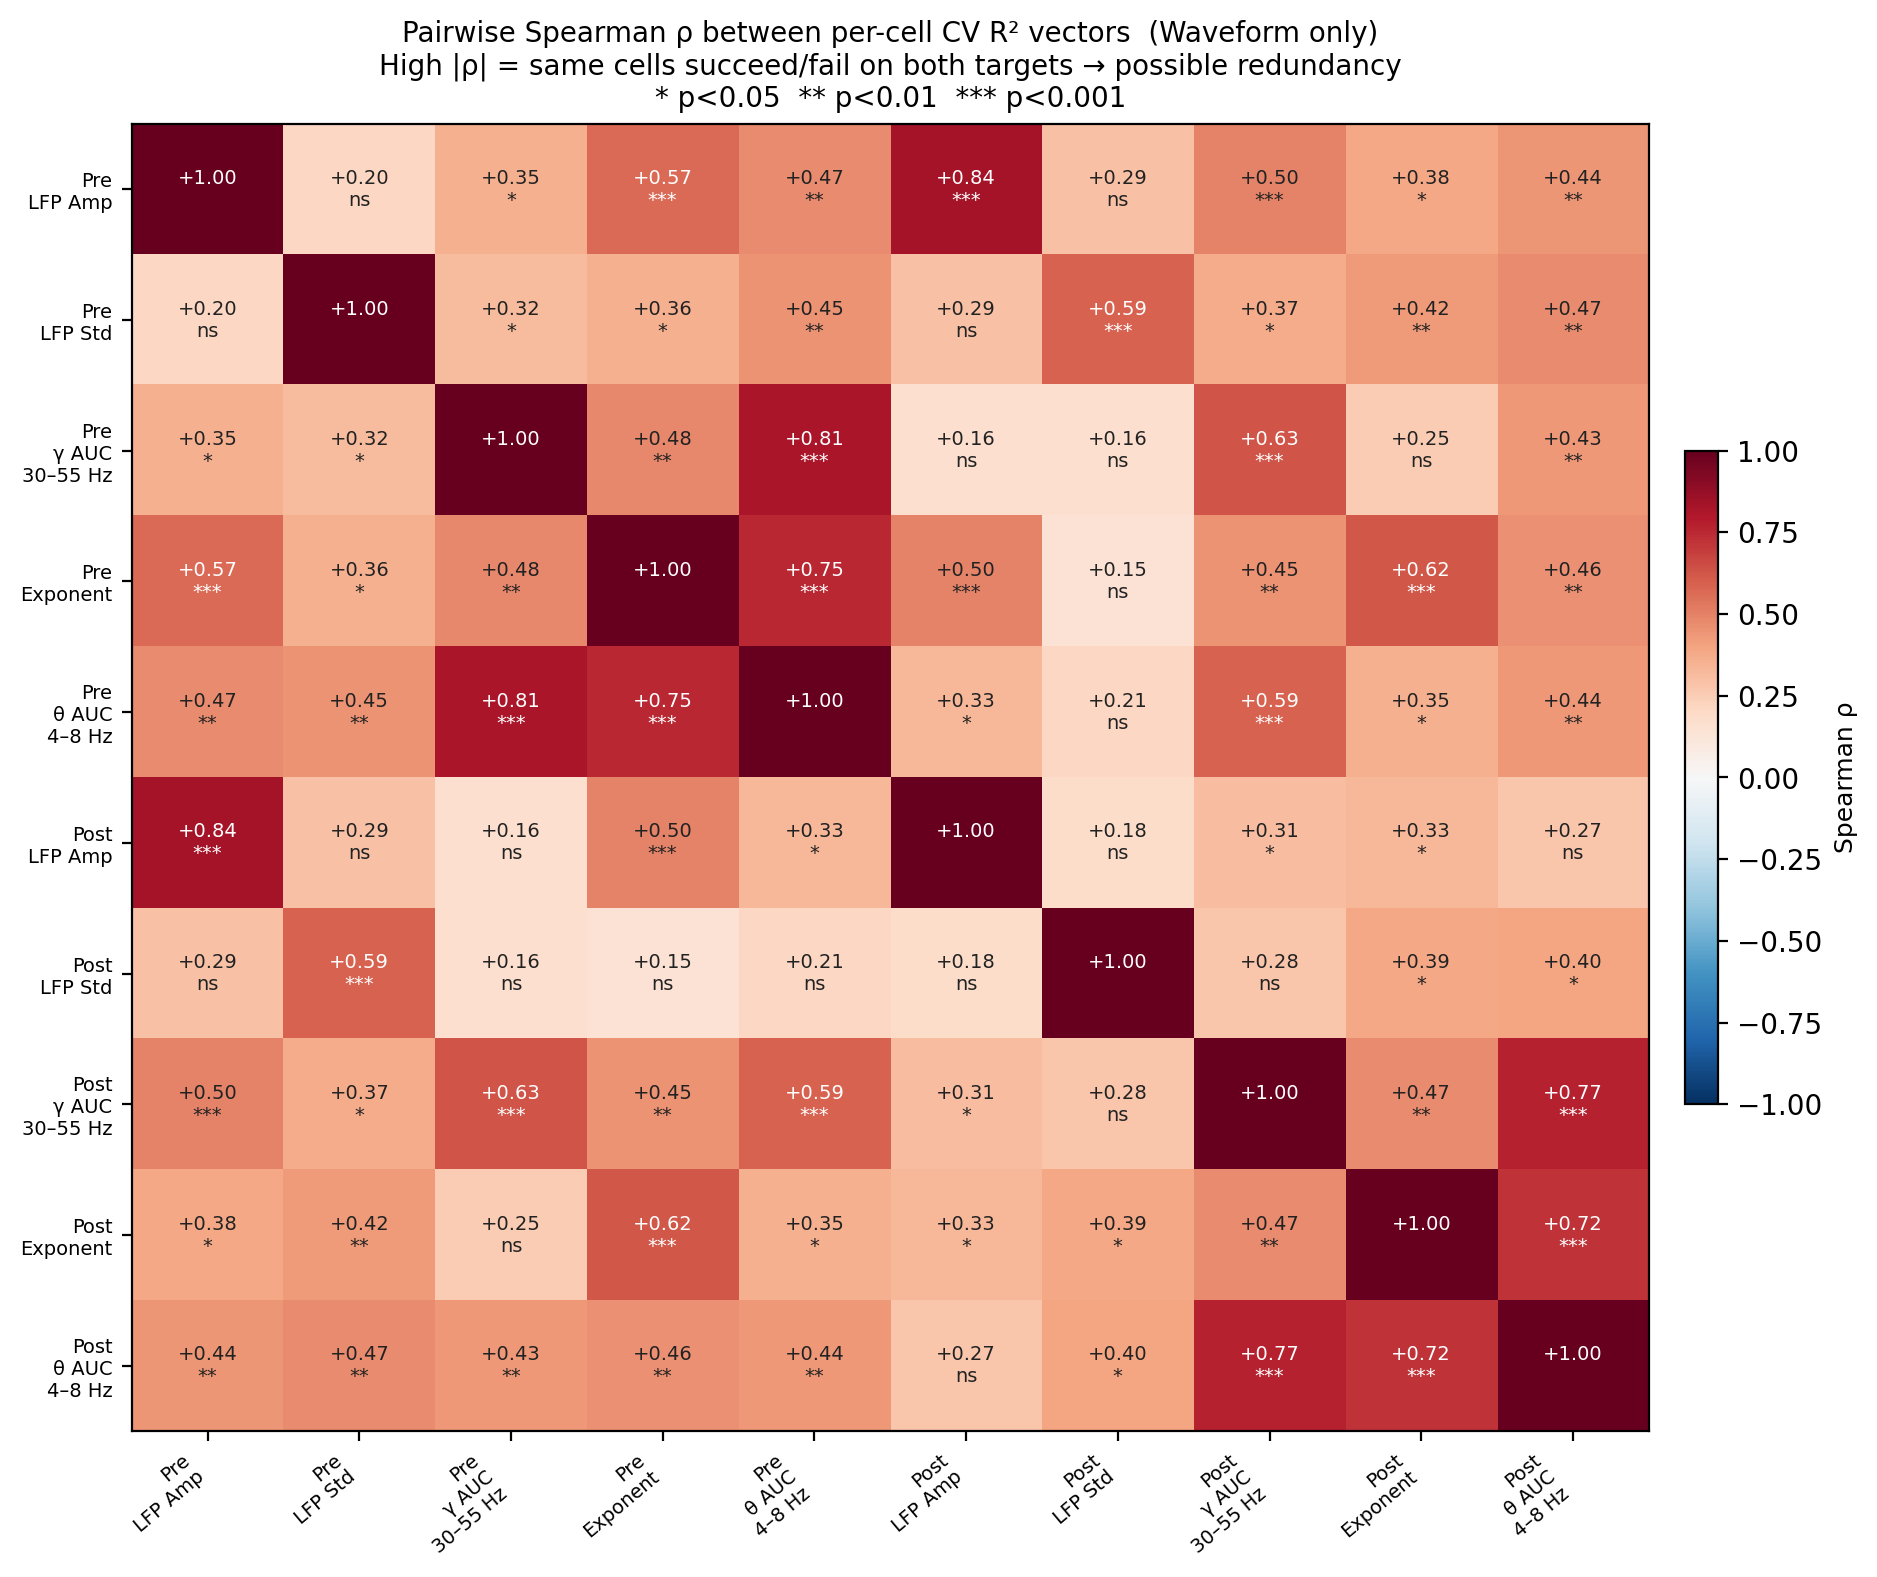


Highly correlated pairs (|ρ| ≥ 0.7):
  Pre LFP Amp                          ×  Post LFP Amp                         ρ = +0.836  p = < 0.0001
  Pre γ AUC
30–55 Hz                   ×  Pre θ AUC
4–8 Hz                     ρ = +0.814  p = < 0.0001
  Post γ AUC
30–55 Hz                  ×  Post θ AUC
4–8 Hz                    ρ = +0.773  p = < 0.0001
  Pre Exponent                         ×  Pre θ AUC
4–8 Hz                     ρ = +0.754  p = < 0.0001
  Post Exponent                        ×  Post θ AUC
4–8 Hz                    ρ = +0.721  p = < 0.0001


In [8]:
# ── 2b. Target correlation check ──────────────────────────────────────────────
# Are any LFP targets redundant? High Spearman ρ between per-cell R² vectors
# means the same cells succeed/fail on both targets → possible redundancy.
plot_target_correlations(r2_pop_psd, target_names_psd, target_labels_psd)

## 2b. Target correlation check

Pairwise Spearman ρ between per-cell R² vectors across all 14 targets. High |ρ| means the same cells succeed/fail on both — suggesting redundancy. Informs whether any targets can be dropped without losing information.

In [9]:
# ── 3. Population tests ───────────────────────────────────────────────────────
df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)

sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
print(f'\nR²-significant targets (Waveform only): {sig_r2_targets}')

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

Fraction-sig binomial tests: 42 pairs  |  p<0.05: 40 (each target tested independently)
      target_label      predictor_set  n_sig  n_cells  frac_sig
       Pre LFP Amp      Waveform only     34       39  0.871795
       Pre LFP Amp       Log ISI only     18       39  0.461538
       Pre LFP Amp Waveform + Log ISI     35       39  0.897436
 Pre LFP Amp (HPF)      Waveform only     25       39  0.641026
 Pre LFP Amp (HPF)       Log ISI only     15       39  0.384615
 Pre LFP Amp (HPF) Waveform + Log ISI     28       39  0.717949
       Pre LFP Std      Waveform only     29       39  0.743590
       Pre LFP Std       Log ISI only     15       39  0.384615
       Pre LFP Std Waveform + Log ISI     32       39  0.820513
 Pre LFP Std (HPF)      Waveform only     19       39  0.487179
 Pre LFP Std (HPF)       Log ISI only     13       39  0.333333
 Pre LFP Std (HPF) Waveform + Log ISI     24       39  0.615385
     Pre Gamma AUC      Waveform only     14       39  0.358974
     Pre Gamma A

In [10]:
# ── 3-psd. Population tests — single-PSD method ─────────────────────────────
df_frac_psd = run_fraction_sig_tests(
    sig_pop_psd, target_names_psd, target_labels_psd, predictor_sets_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2_psd = run_r2_tests(
    r2_pop_psd, target_names_psd, target_labels_psd, predictor_sets_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets_psd = (
    df_r2_psd[df_r2_psd['sig_r2'] & (df_r2_psd['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
df_tests_psd = run_population_tests(
    beta_pop_psd, target_names_psd, target_labels_psd,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets_psd,
)

Fraction-sig binomial tests: 30 pairs  |  p<0.05: 29 (each target tested independently)
        target_label      predictor_set  n_sig  n_cells  frac_sig
         Pre LFP Amp      Waveform only     27       42  0.642857
         Pre LFP Amp       Log ISI only     15       42  0.357143
         Pre LFP Amp Waveform + Log ISI     30       42  0.714286
         Pre LFP Std      Waveform only     19       42  0.452381
         Pre LFP Std       Log ISI only     12       42  0.285714
         Pre LFP Std Waveform + Log ISI     24       42  0.571429
 Pre γ AUC\n30–55 Hz      Waveform only     14       42  0.333333
 Pre γ AUC\n30–55 Hz       Log ISI only     13       42  0.309524
 Pre γ AUC\n30–55 Hz Waveform + Log ISI     19       42  0.452381
        Pre Exponent      Waveform only      8       42  0.190476
        Pre Exponent       Log ISI only      6       42  0.142857
        Pre Exponent Waveform + Log ISI     11       42  0.261905
   Pre θ AUC\n4–8 Hz      Waveform only     11       4

In [11]:
# ── 3c. Beta tables — R²-significant targets ──────────────────────────────────
show_beta_tables(df_tests, sig_r2_targets, target_names, target_labels, r2_pop=r2_pop)

,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Ramp Amp,39,-0.0174,0.0063,0.0268,*
1,Sharpness,39,-0.0493,0.0284,0.0400,*
2,Infl. Amp,39,+0.0298,0.0152,0.0459,*
3,Infl. Time,39,+0.0104,0.0076,0.0704,ns
4,Decay λ,39,+0.0256,0.0126,0.1240,ns
5,Peak Width,39,-0.0315,0.0210,0.1625,ns
6,Peak Amp,39,+0.0407,0.0392,0.5854,ns
7,Decay Const,39,-0.0033,0.0114,0.6046,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Infl. Amp,39,+0.0221,0.0092,0.0098,**
1,Sharpness,39,-0.0463,0.0311,0.1275,ns
2,Infl. Time,39,+0.0057,0.0047,0.2706,ns
3,Ramp Amp,39,-0.0058,0.0047,0.3721,ns
4,Decay Const,39,+0.0064,0.0085,0.6940,ns
5,Peak Amp,39,+0.0263,0.0303,0.7043,ns
6,Decay λ,39,-0.0059,0.0099,0.7249,ns
7,Peak Width,39,-0.0008,0.0131,0.7985,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Decay Const,39,+0.0082,0.0098,0.0929,ns
1,Infl. Time,39,-0.0026,0.0053,0.2248,ns
2,Ramp Amp,39,+0.0036,0.0032,0.3949,ns
3,Sharpness,39,+0.0063,0.0121,0.5572,ns
4,Infl. Amp,39,-0.0068,0.0074,0.6737,ns
5,Peak Width,39,+0.0039,0.0129,0.6940,ns
6,Decay λ,39,-0.0006,0.0086,0.8957,ns
7,Peak Amp,39,-0.0105,0.0210,0.9945,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Sharpness,39,-0.0533,0.0280,0.0175,*
1,Infl. Amp,39,+0.0309,0.0150,0.0359,*
2,Ramp Amp,39,-0.0161,0.0061,0.0372,*
3,Decay λ,39,+0.0255,0.0122,0.1385,ns
4,Infl. Time,39,+0.0064,0.0074,0.2195,ns
5,Peak Width,39,-0.0169,0.0189,0.3949,ns
6,Peak Amp,39,+0.0486,0.0378,0.4105,ns
7,Decay Const,39,-0.0063,0.0107,0.4852,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Sharpness,39,-0.0695,0.0261,0.0508,ns
1,Infl. Amp,39,+0.0205,0.0100,0.1711,ns
2,Ramp Amp,39,-0.0098,0.0049,0.2195,ns
3,Infl. Time,39,+0.0043,0.0043,0.2469,ns
4,Peak Width,39,-0.0081,0.0122,0.7985,ns
5,Decay λ,39,+0.0003,0.0077,0.8414,ns
6,Decay Const,39,-0.0022,0.0096,0.9615,ns
7,Peak Amp,39,+0.0334,0.0303,0.9945,ns


,Feature,N cells,Mean β,SEM β,p (Wilcoxon),sig
0,Decay Const,39,+0.0094,0.0095,0.0400,*
1,Peak Width,39,+0.0101,0.0132,0.1625,ns
2,Infl. Time,39,-0.0007,0.0054,0.4185,ns
3,Ramp Amp,39,+0.0037,0.0034,0.5027,ns
4,Decay λ,39,-0.0016,0.0082,0.5296,ns
5,Sharpness,39,+0.0035,0.0104,0.6637,ns
6,Peak Amp,39,-0.0119,0.0199,0.8739,ns
7,Infl. Amp,39,-0.0019,0.0066,0.9725,ns


## 3. Population tests

**R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. Primary test — is the median effect size above zero? Each target assessed at α = 0.05 independently.

**Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of cells with p < 0.05 (per target, per cell) greater than the chance level of 5%? Each target tested independently.

**Beta consistency** (`run_population_tests`): one-sample t-test + Wilcoxon on beta weights across cells — do they have a consistent non-zero direction? Restricted to R²-significant targets; within each target, assessed across 8 waveform features.

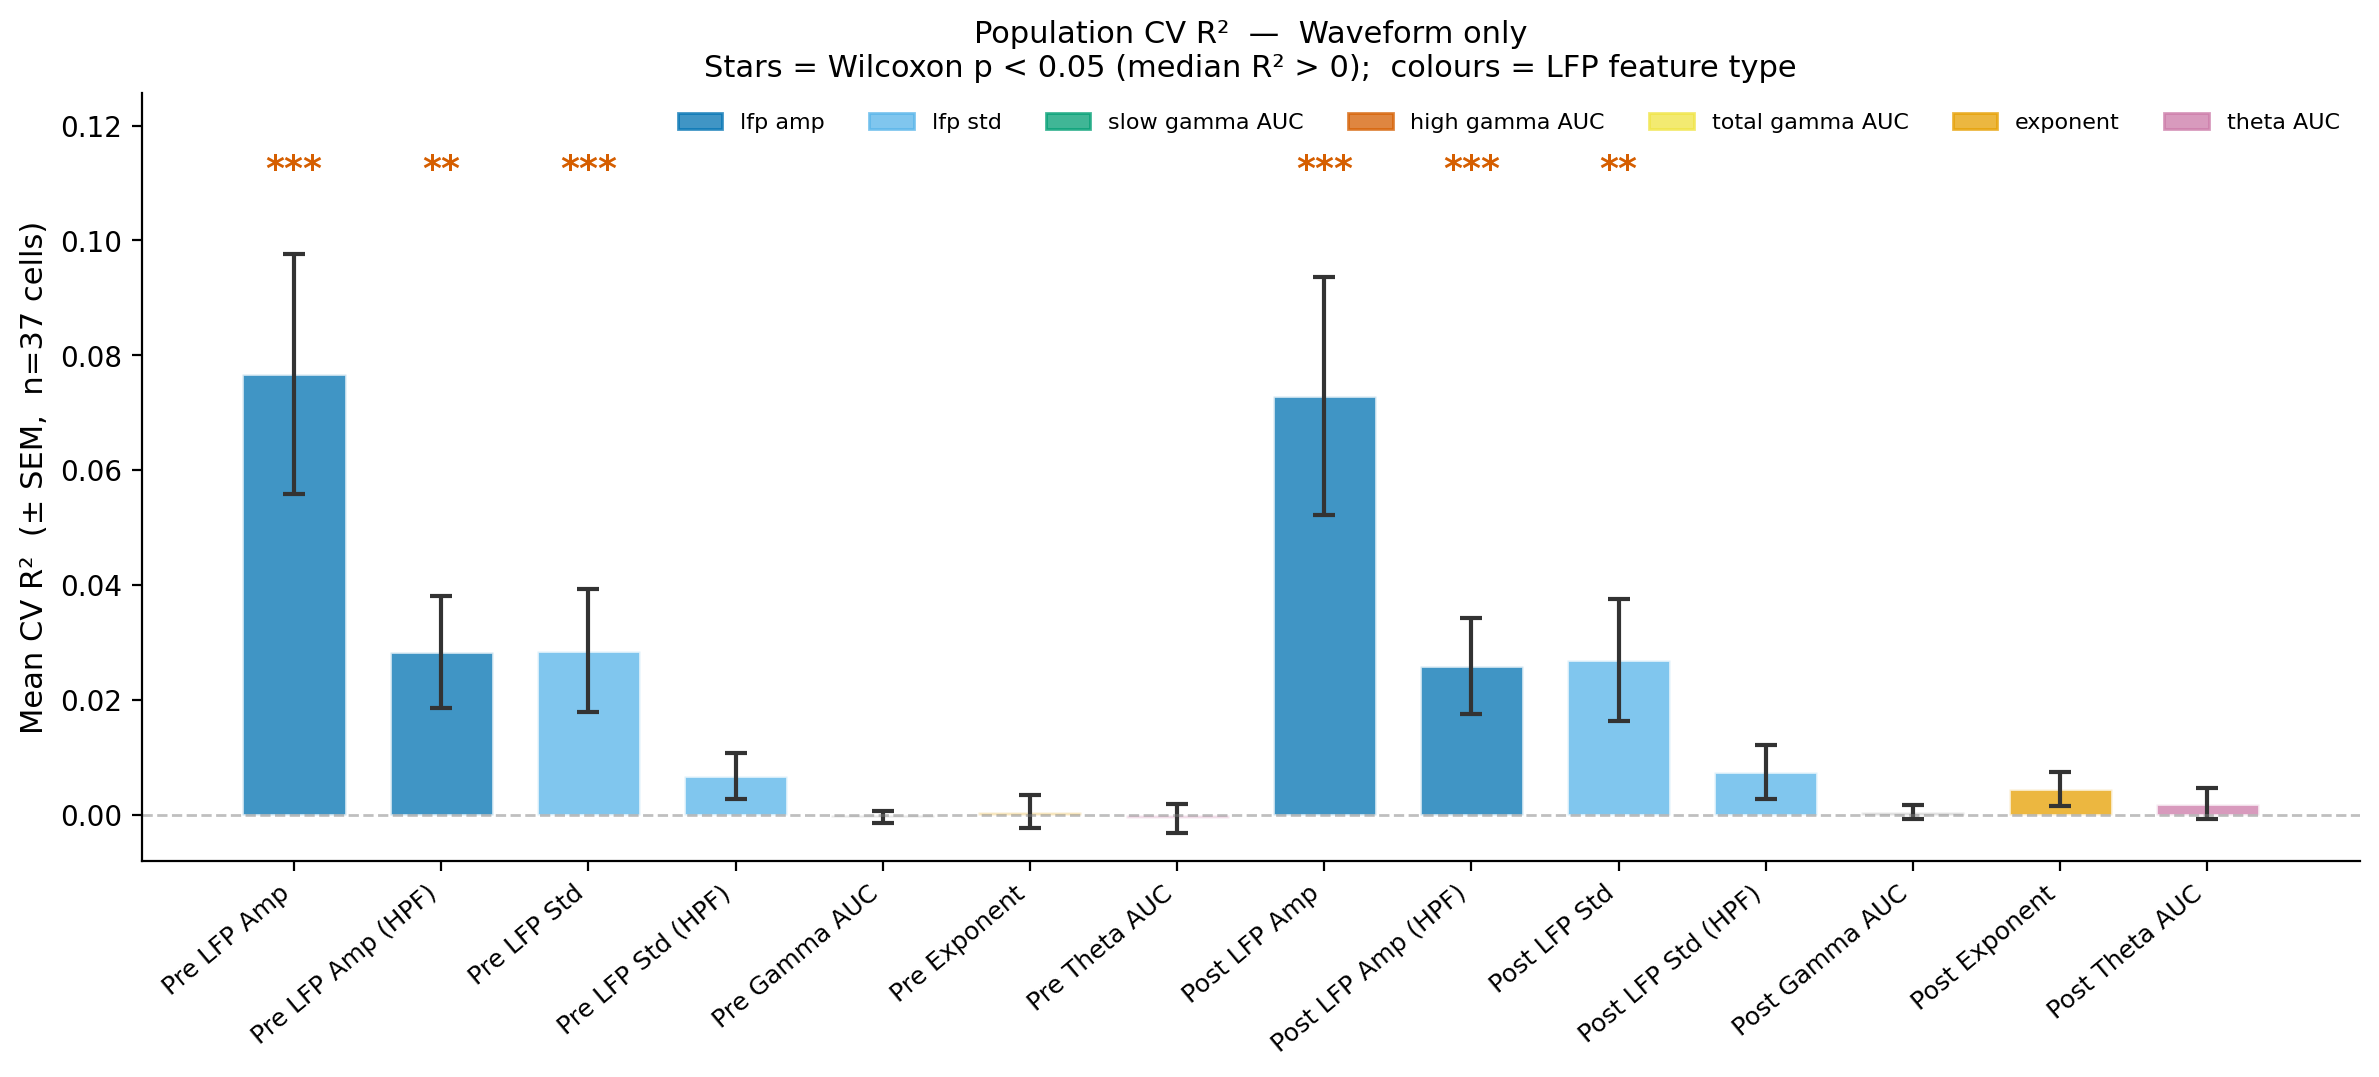

In [12]:
# ── 3d. R² summary — mean ± SEM per target with significance stars ─────────────
plot_r2_summary(r2_pop, df_r2, target_names, target_labels)

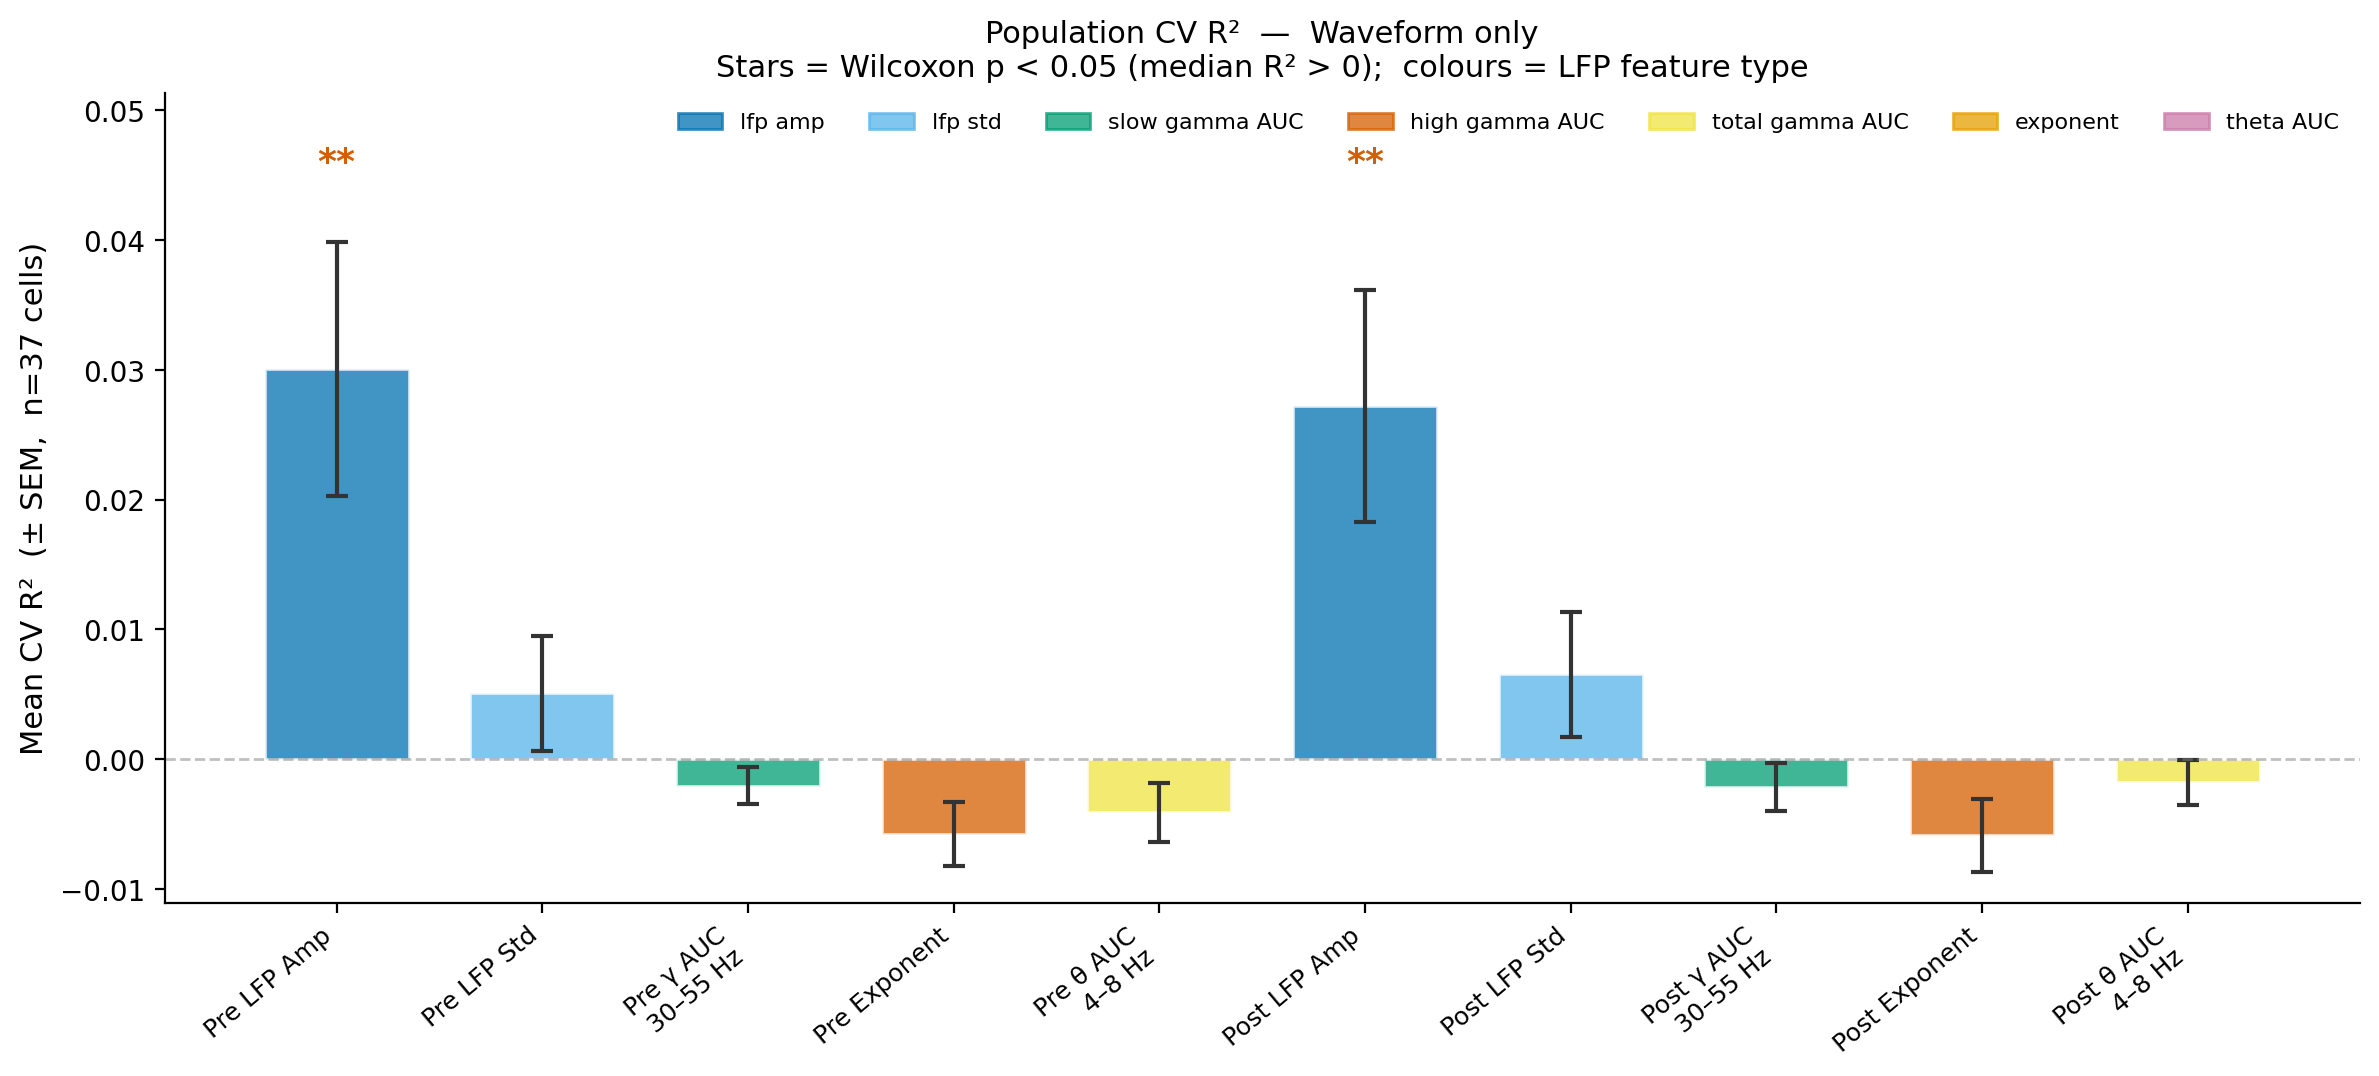

In [13]:
# ── 3d-psd. R² summary — single-PSD method (compare with sliding-window above)
plot_r2_summary(r2_pop_psd, df_r2_psd, target_names_psd, target_labels_psd)

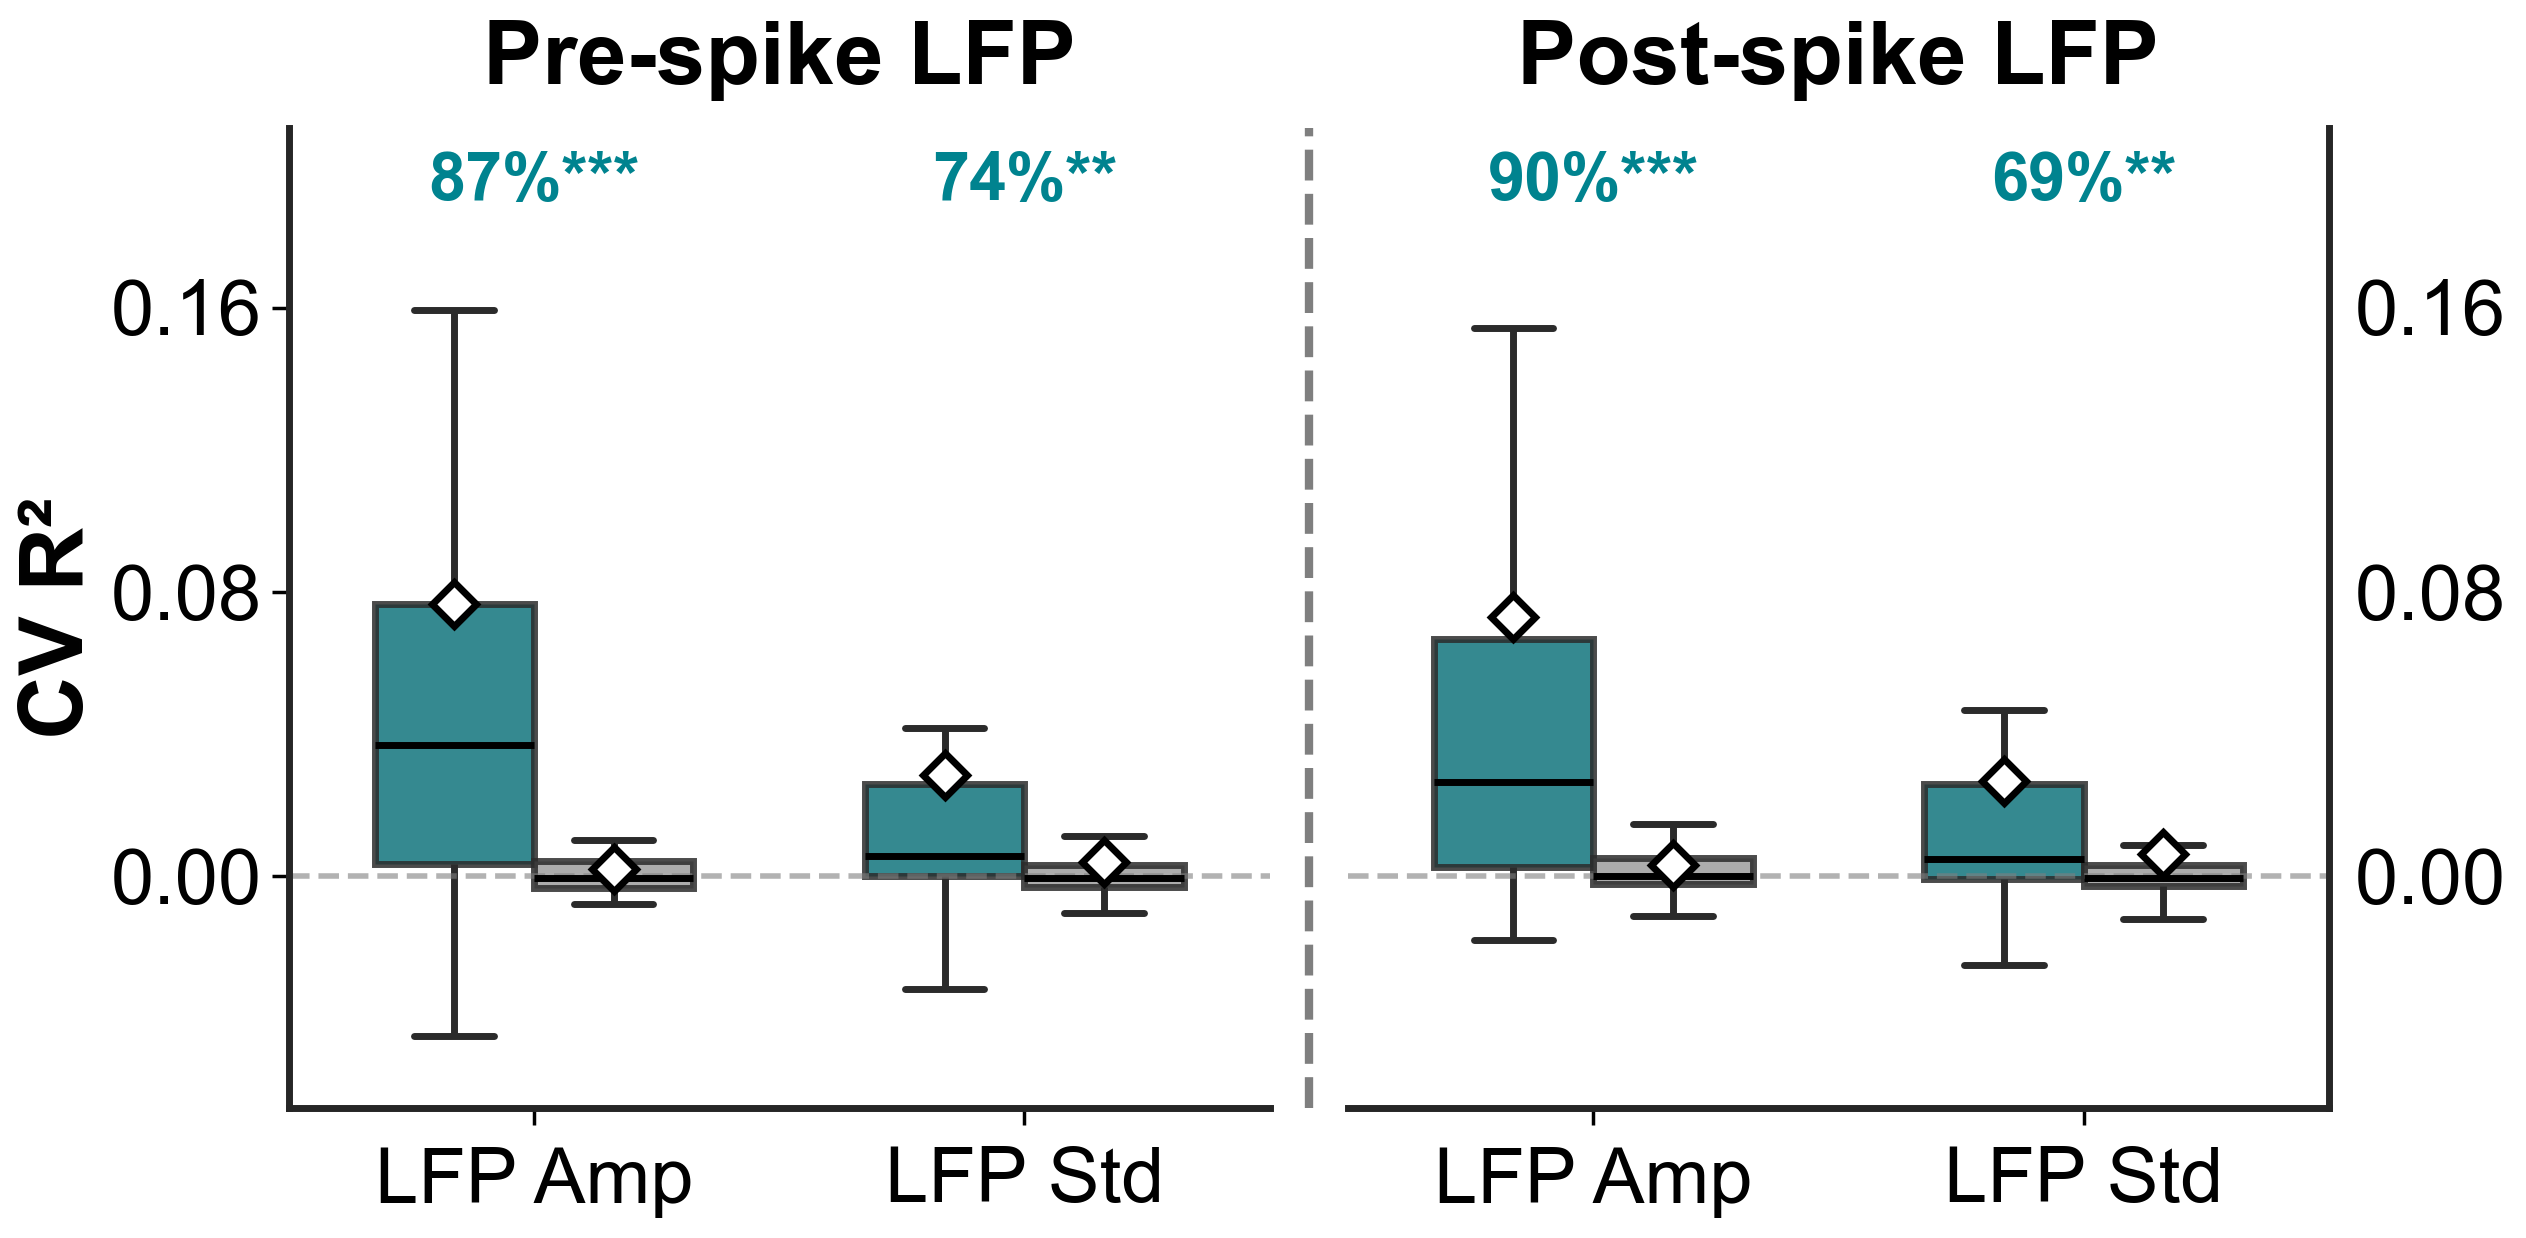

(<Figure size 1200x700 with 2 Axes>,
 array([<Axes: title={'center': 'Pre-spike LFP'}, ylabel='CV R²'>,
        <Axes: title={'center': 'Post-spike LFP'}>], dtype=object),
 <Figure size 280x220 with 1 Axes>)

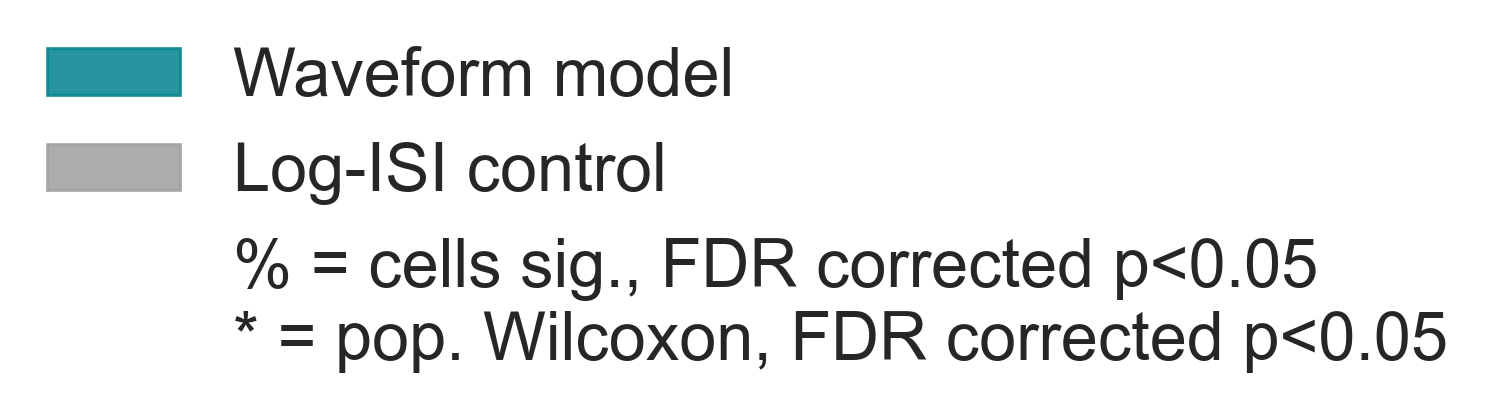

In [14]:
# ── 3e. R² boxplot — cartoony, core (non-HPF) targets only ───────────────────
import importlib, pop_ridge_utils
importlib.reload(pop_ridge_utils)
from pop_ridge_utils import plot_r2_summary_boxplot

plot_r2_summary_boxplot(r2_pop, sig_pop, df_r2, target_names, target_labels,
                        predictor_set='Waveform only')

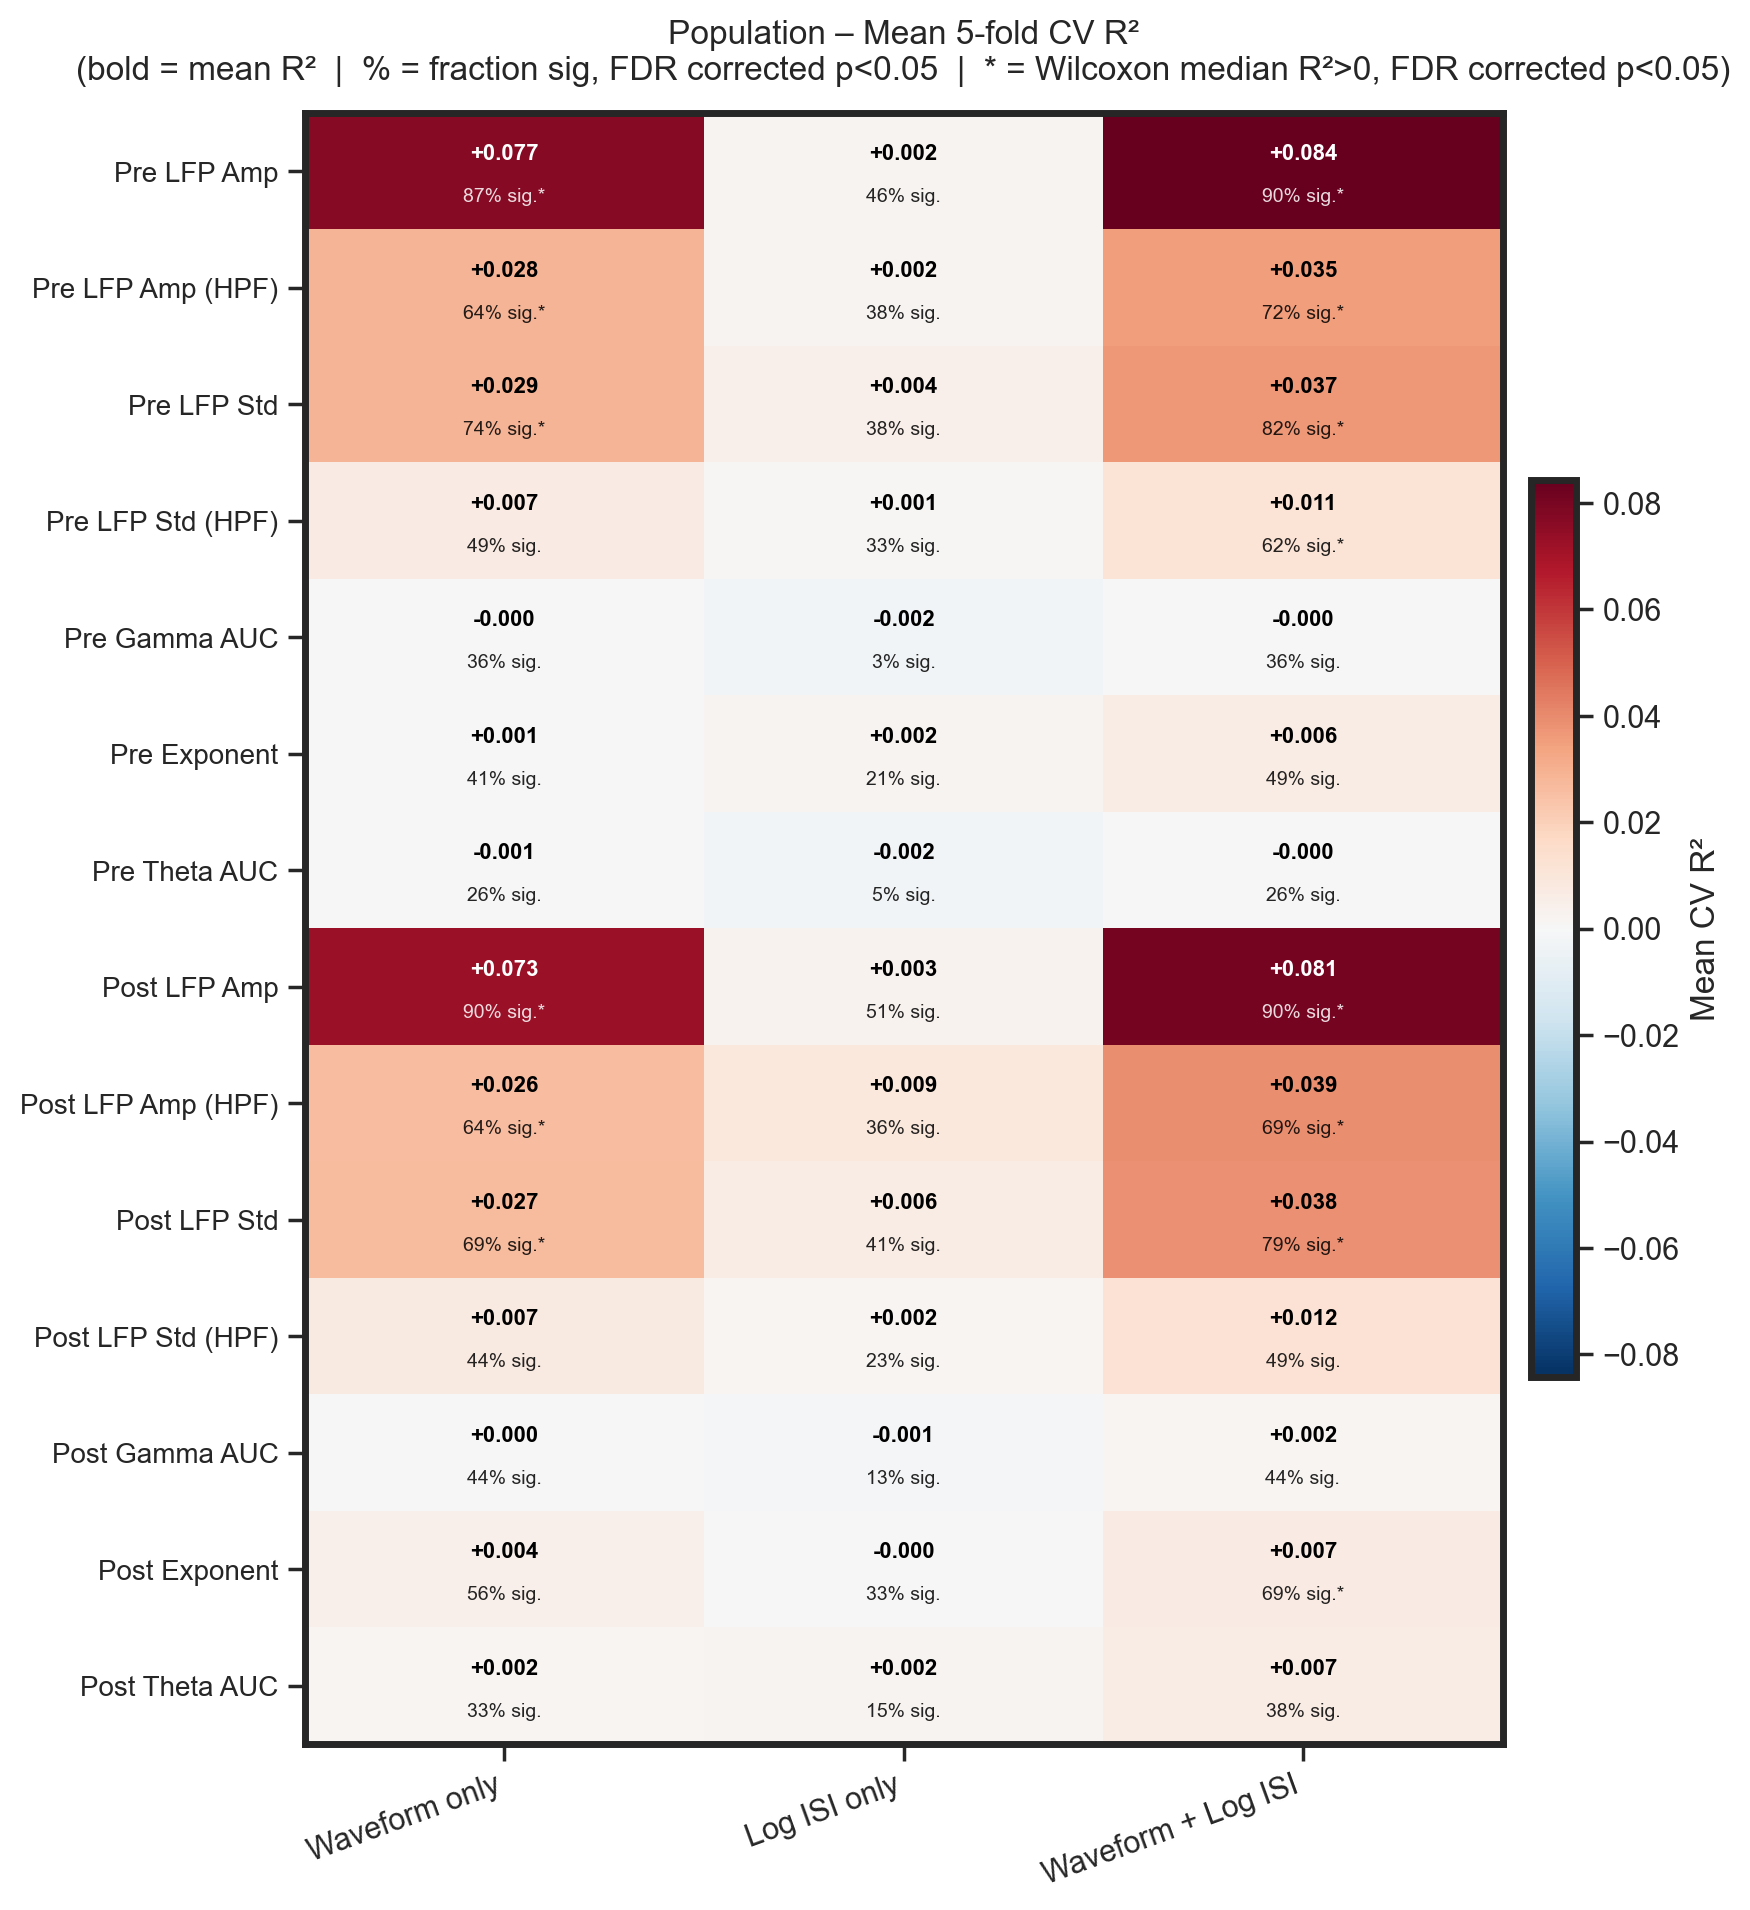

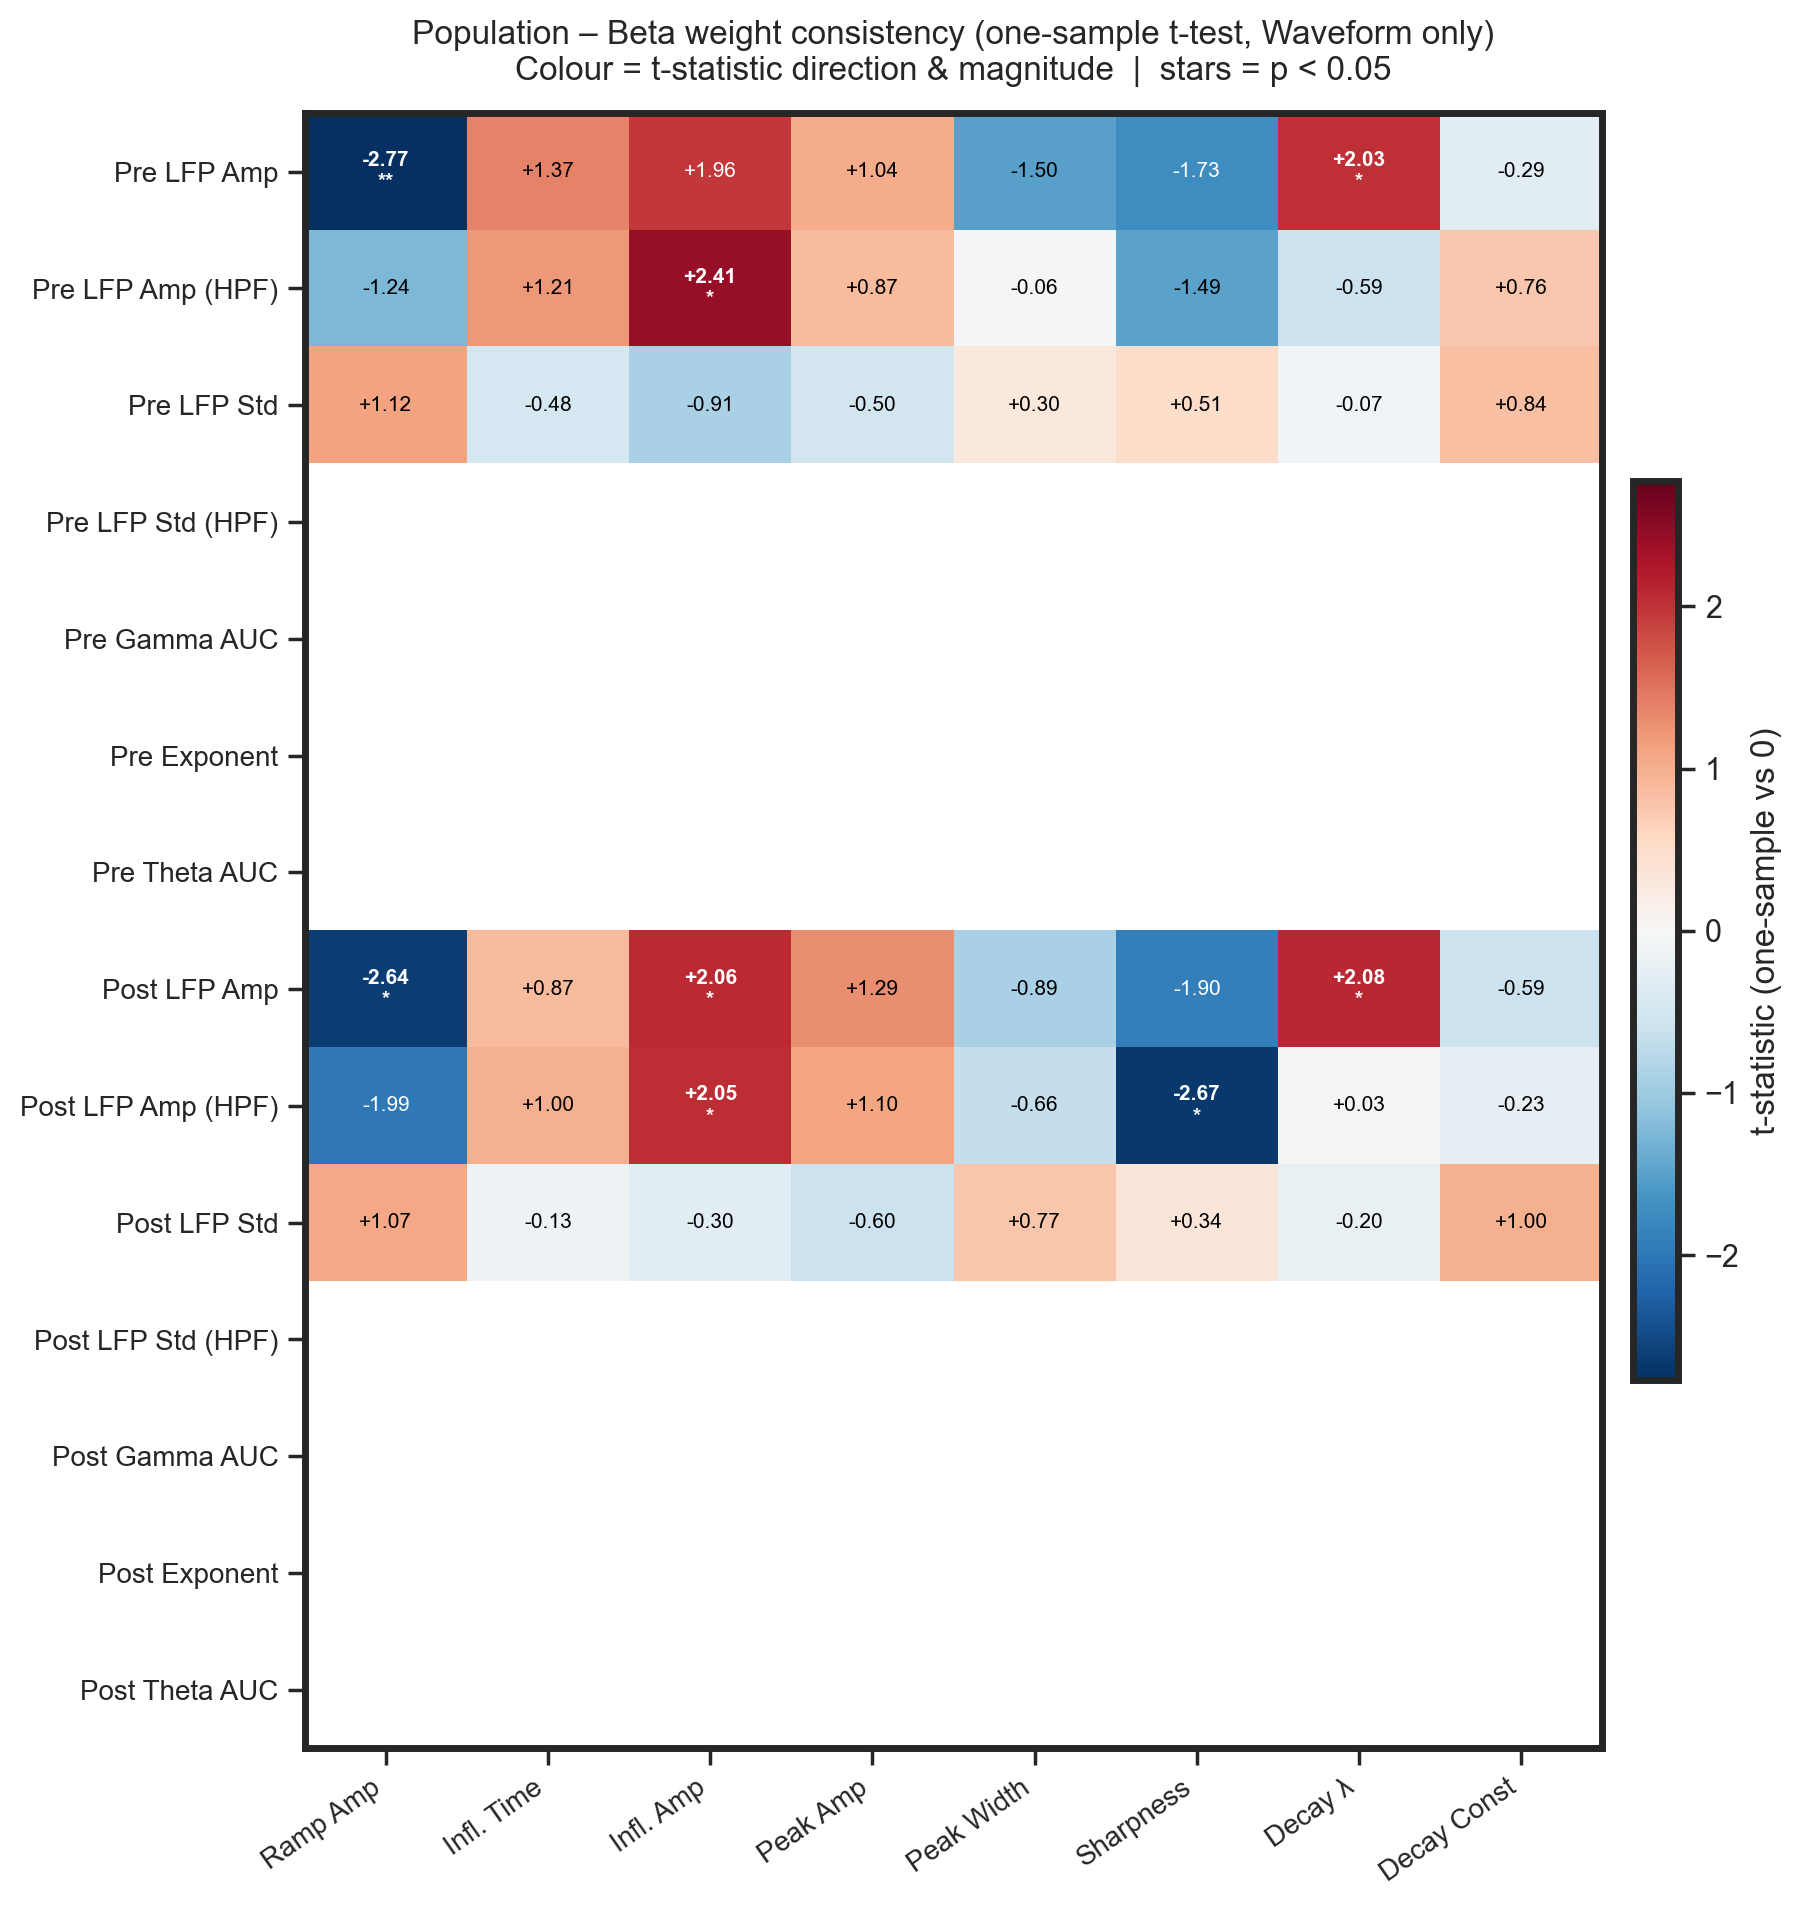

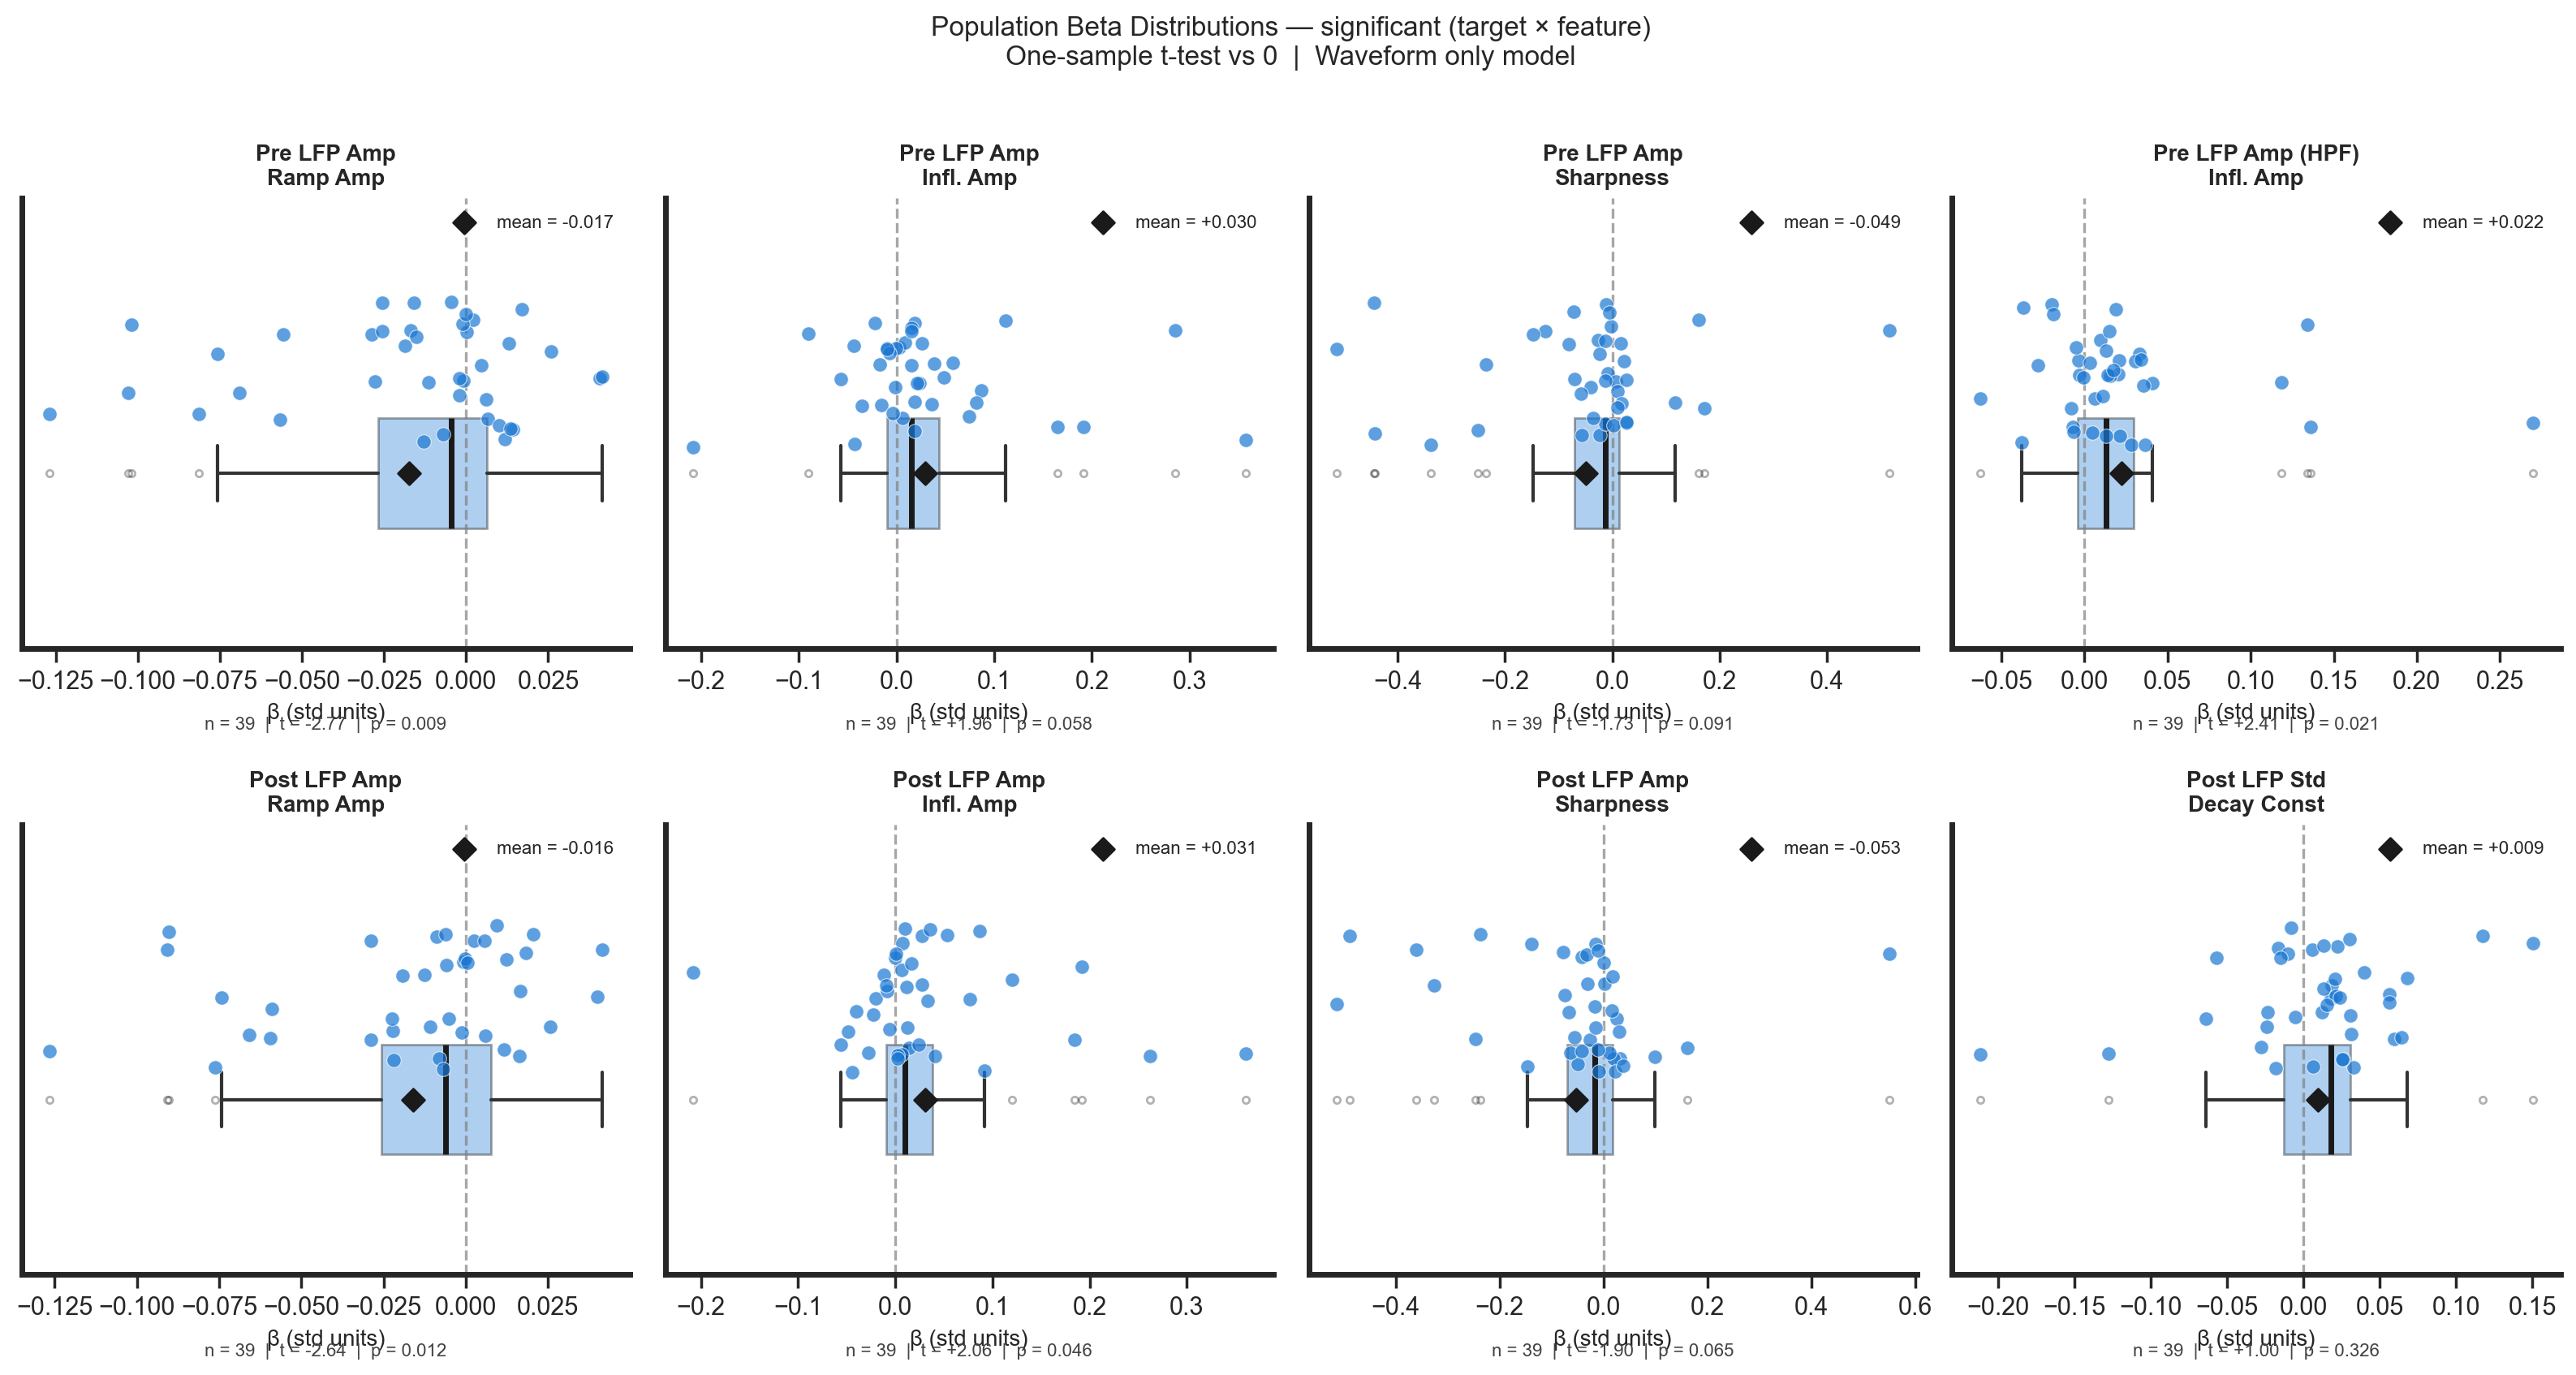

In [15]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
    df_frac=df_frac, df_r2=df_r2,
)

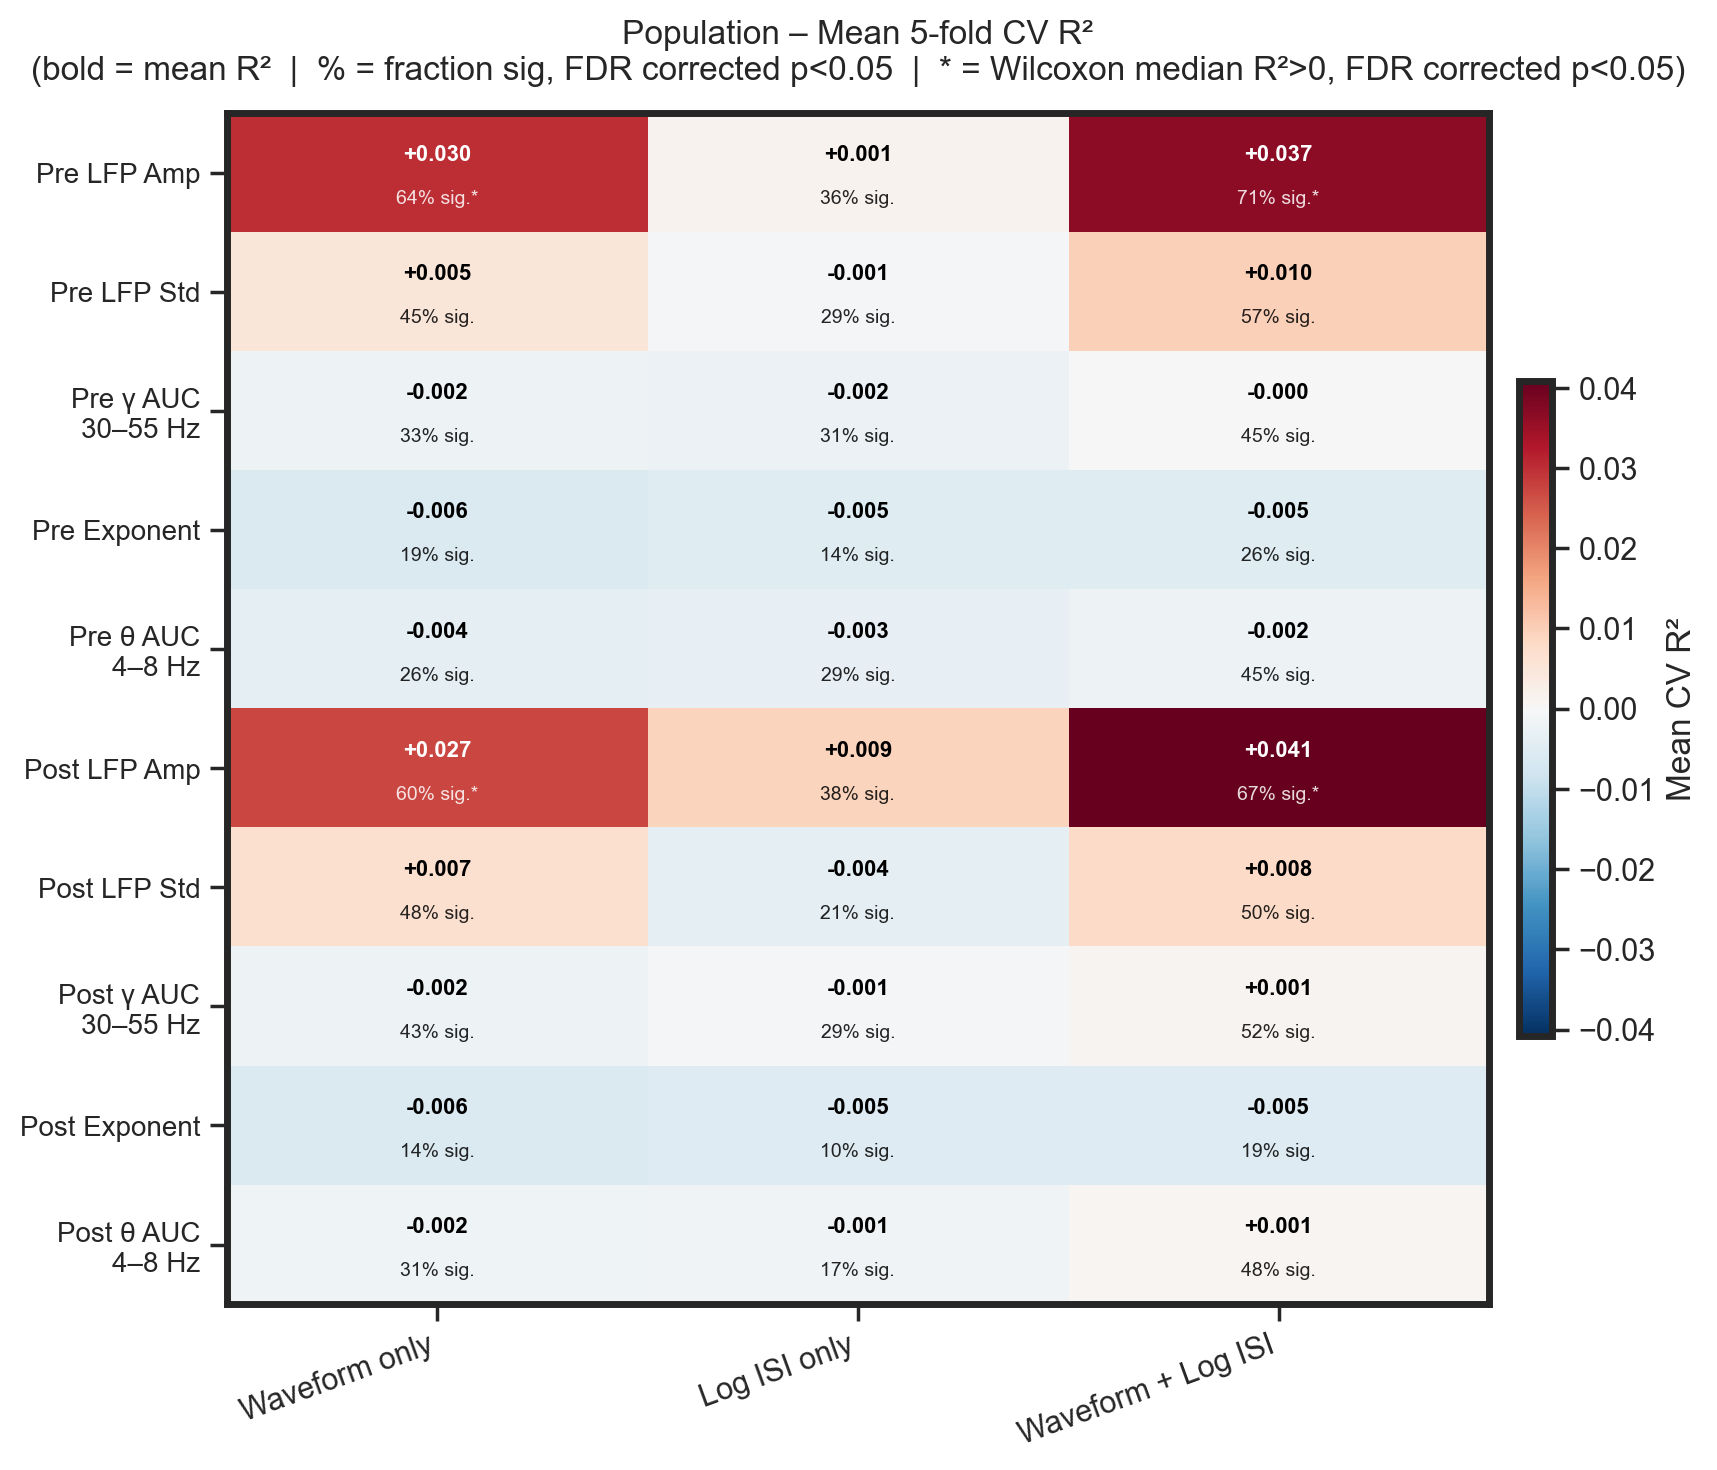

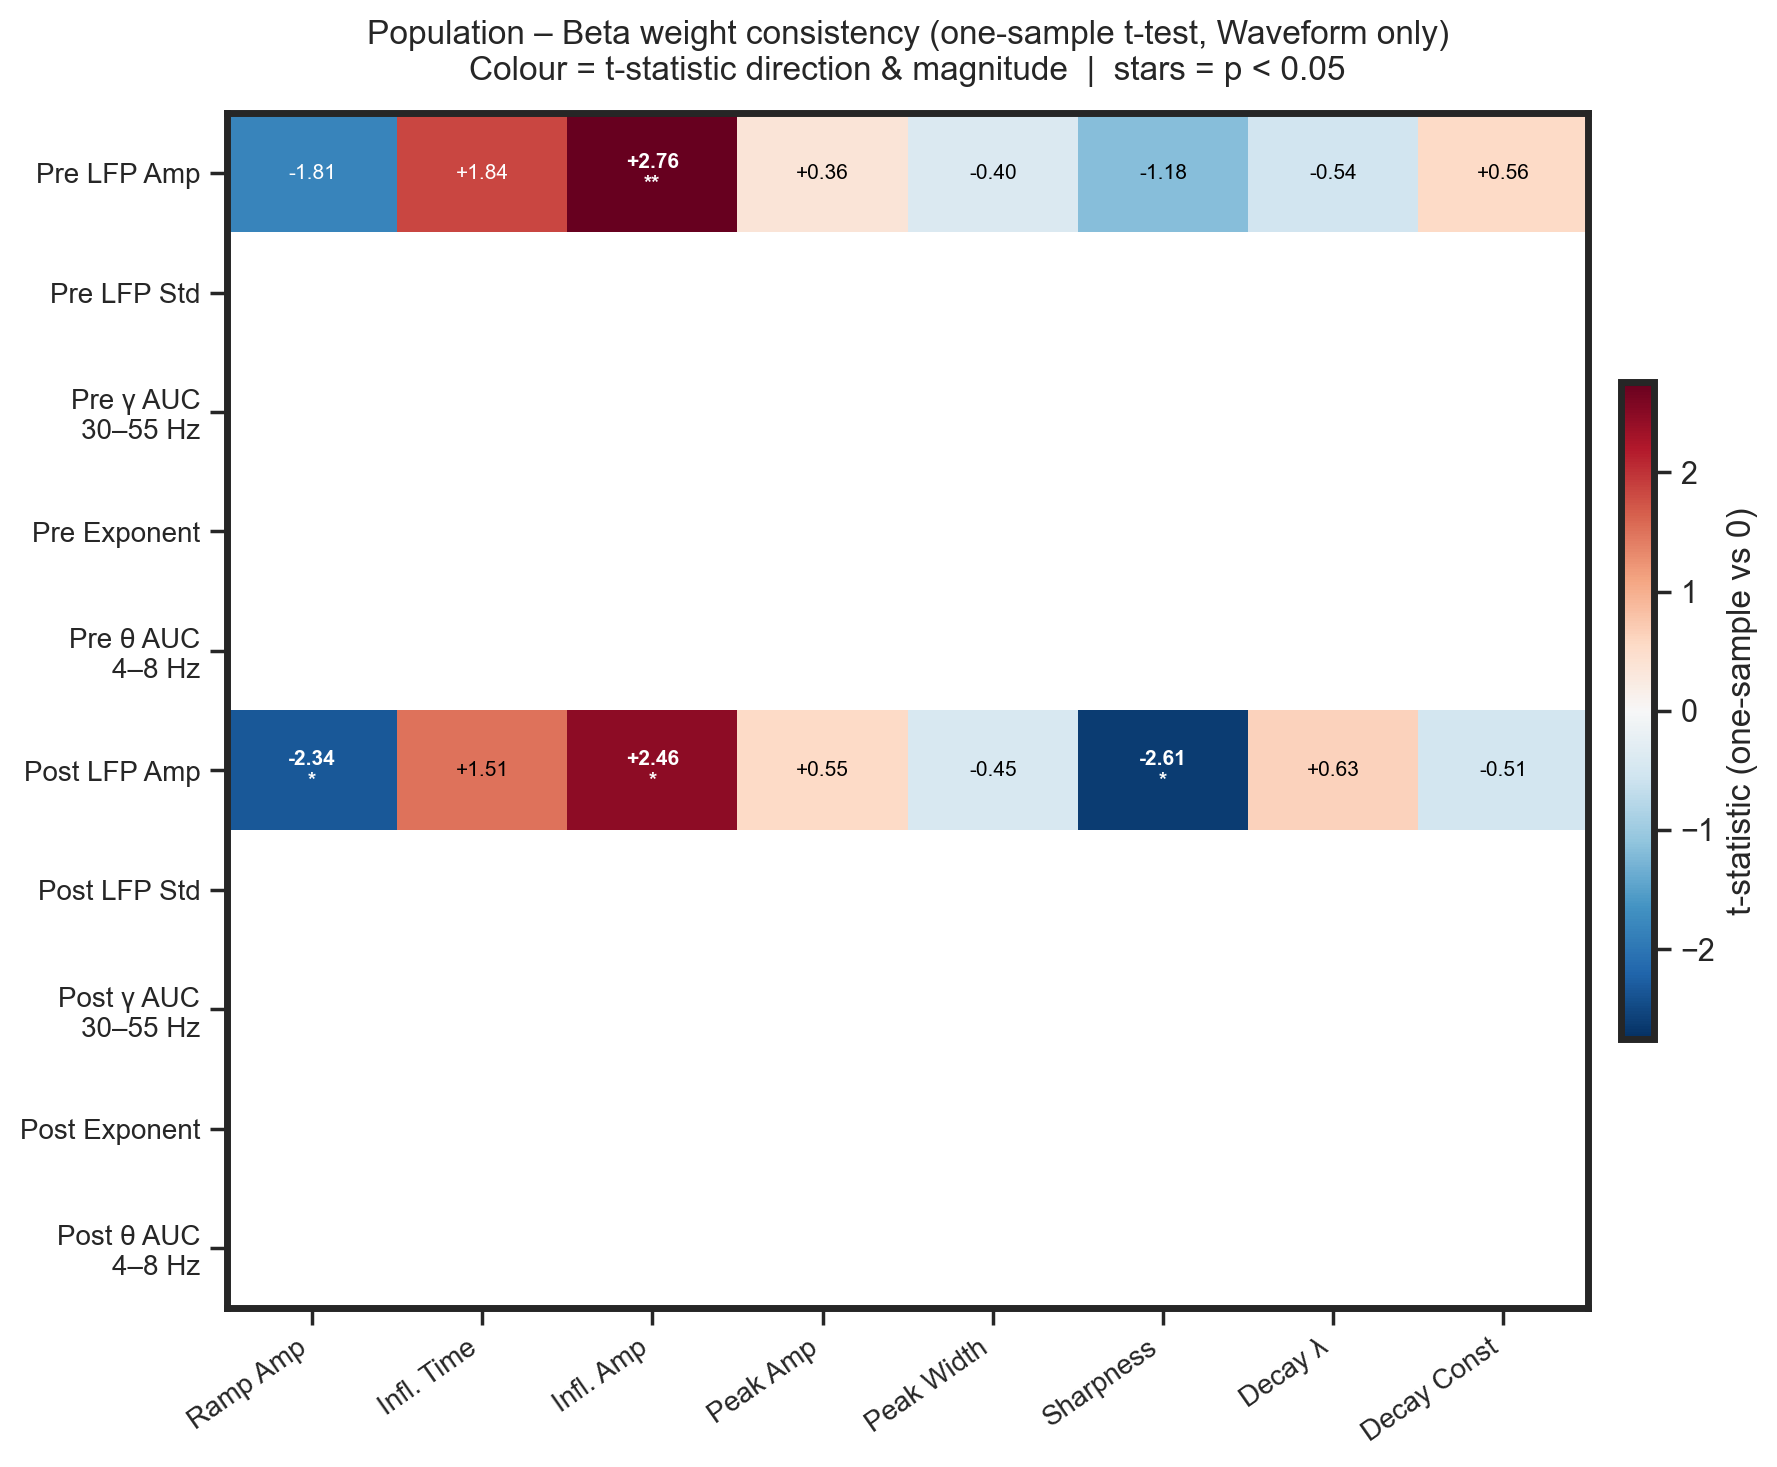

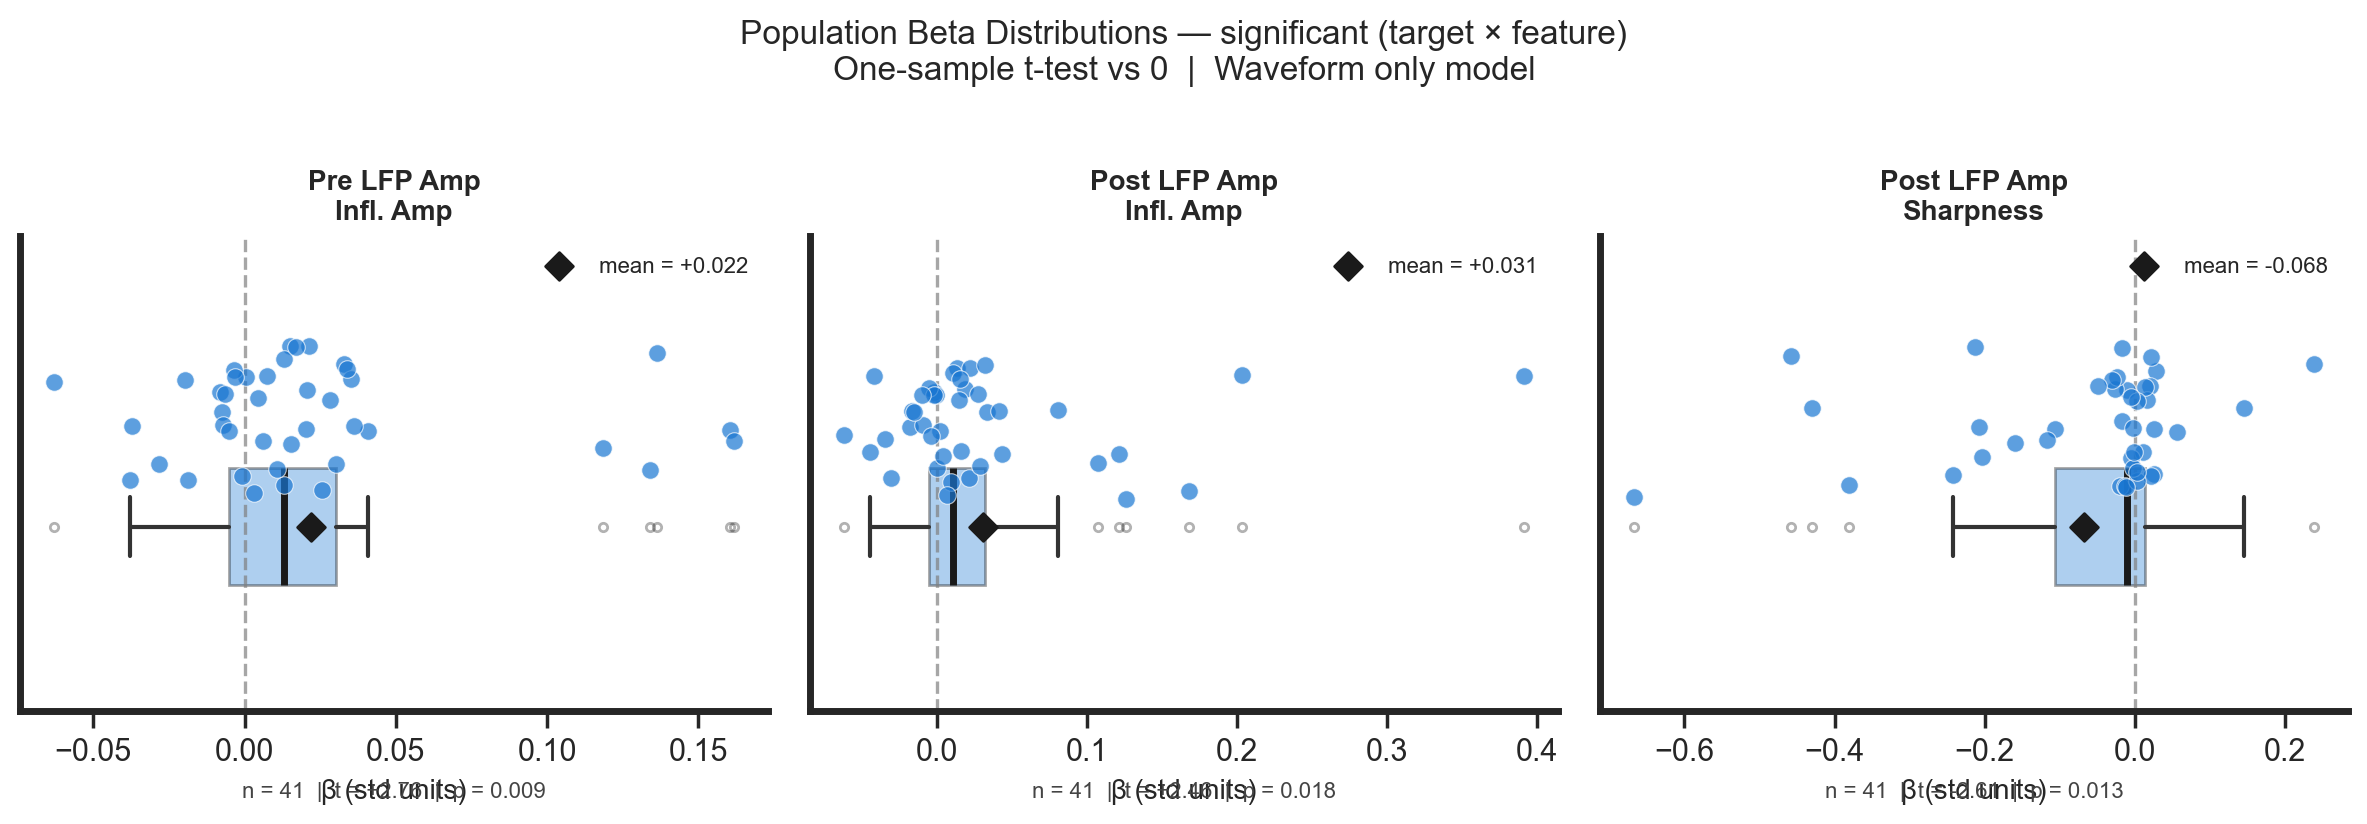

In [16]:
# ── 4-psd. R² heatmap + betas — single-PSD method ───────────────────────────
mean_r2_psd, frac_sig_psd, mean_beta_mat_psd, sig_beta_mat_psd = plot_population_results(
    r2_pop_psd, sig_pop_psd, beta_pop_psd, df_tests_psd,
    target_names_psd, target_labels_psd, predictor_sets_psd,
    df_frac=df_frac_psd, df_r2=df_r2_psd,
)

## 4. Visualisations

R² heatmap (targets × predictor sets), mean beta weight heatmap, per-cell R² distributions, and per-cell beta distributions. Stars on beta heatmap = significant Wilcoxon on that (target × feature) pair (p < 0.05, assessed within each target).

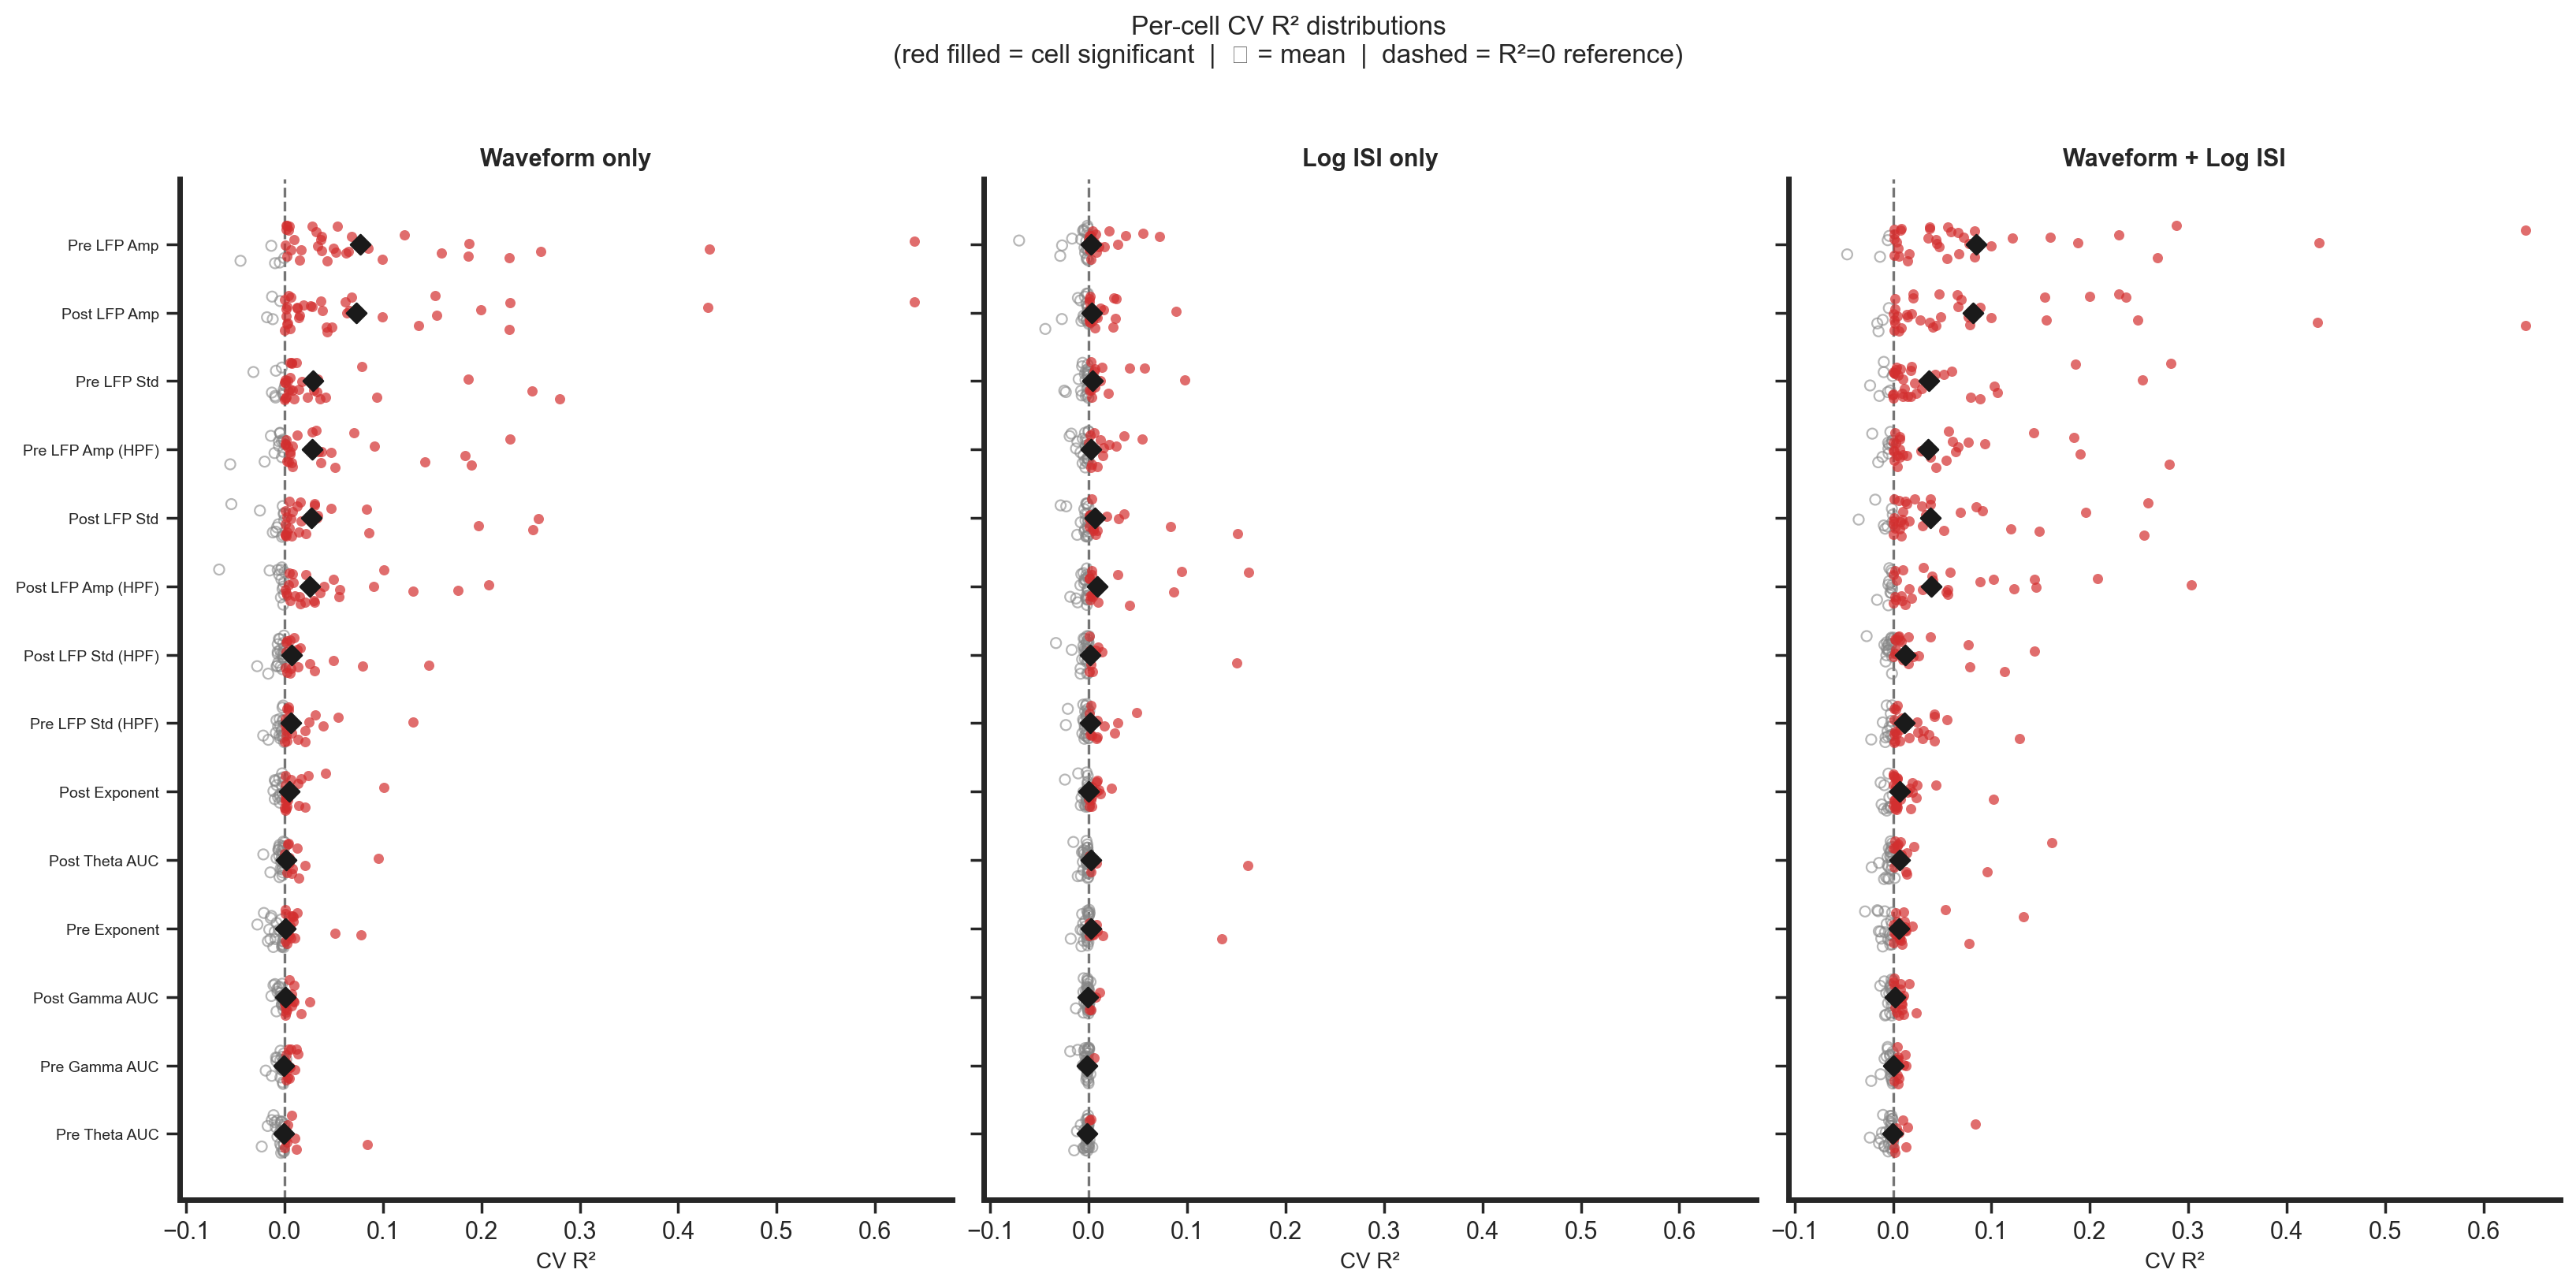

In [17]:
# ── 4b. R² distribution across cells ─────────────────────────────────────────
plot_r2_distributions(
    r2_pop, sig_pop, target_names, target_labels, predictor_sets,
    sort_by='Waveform only', min_r2_line=0.01,
)

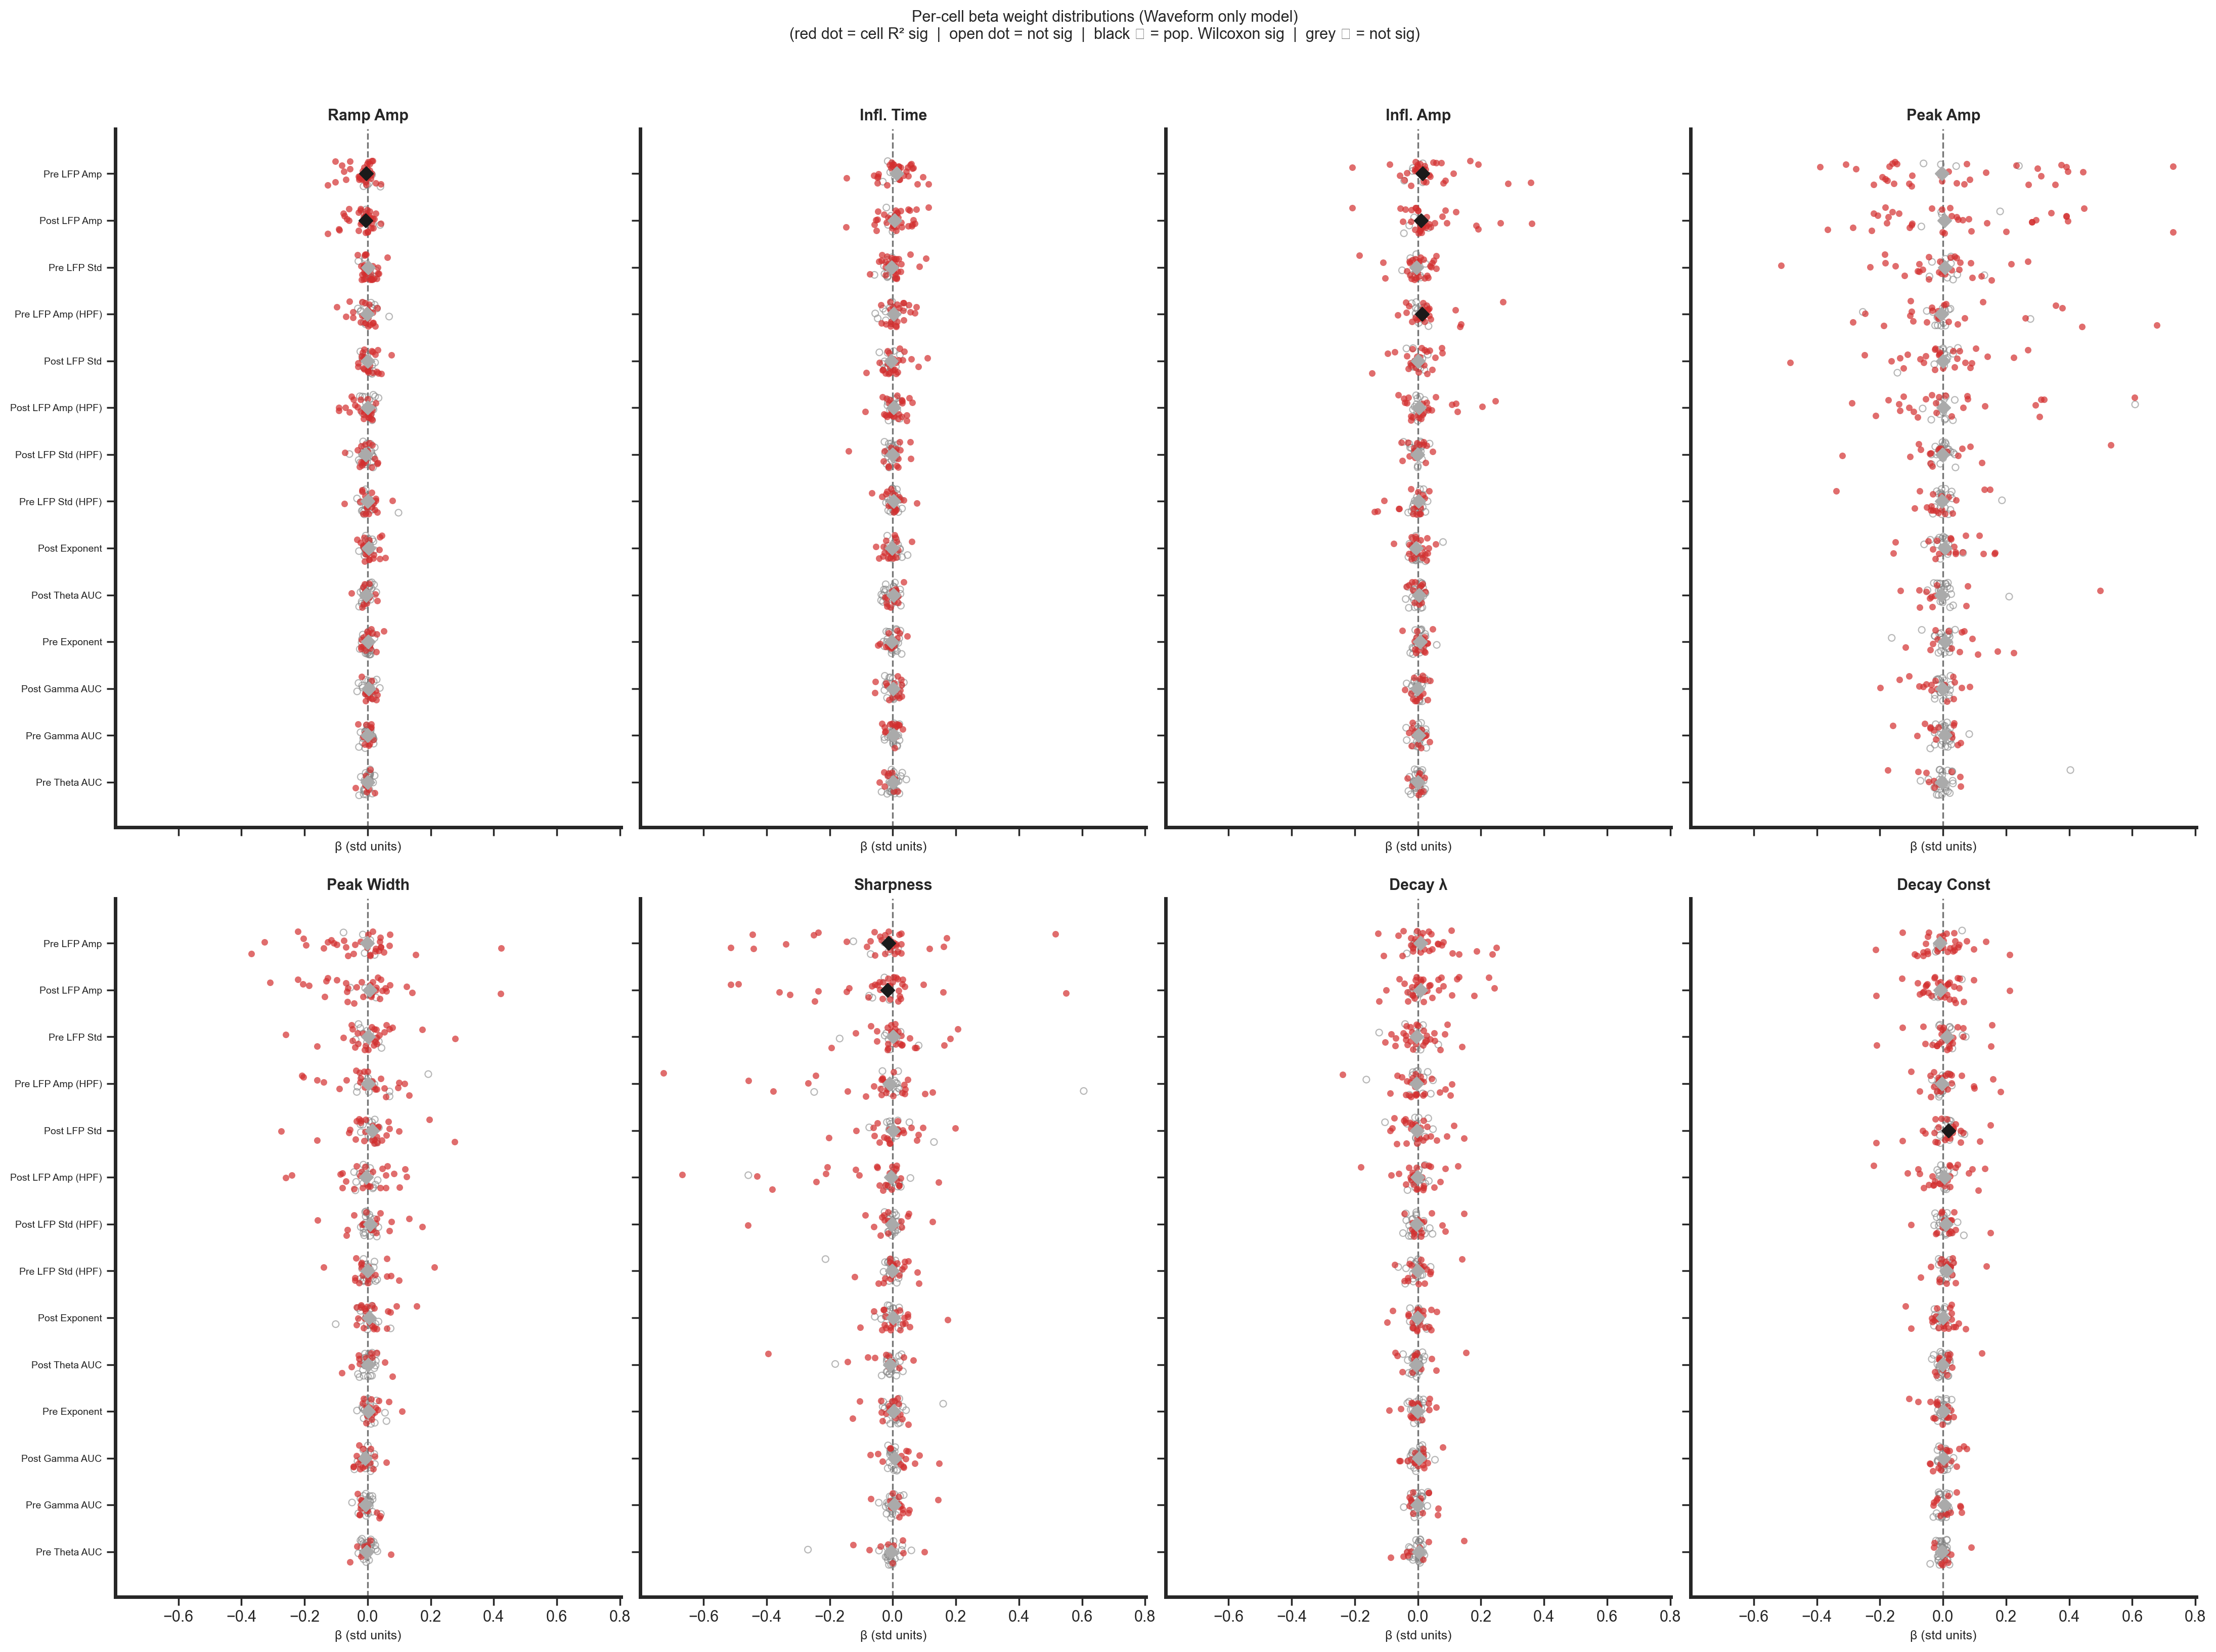

In [18]:
# ── 4c. Beta distributions across cells ──────────────────────────────────────
# One panel per waveform feature; targets sorted by mean R².
# Dot colour: red = that cell's model was significant (raw p < 0.05); grey = not.
# Median ◆: black = population Wilcoxon significant for that (target × feature) pair.
plot_beta_distributions(beta_pop, df_tests, target_names, target_labels,
                        sig_pop=sig_pop, sig_pset='Waveform only',
                        sort_by='mean_r2', r2_pop=r2_pop)

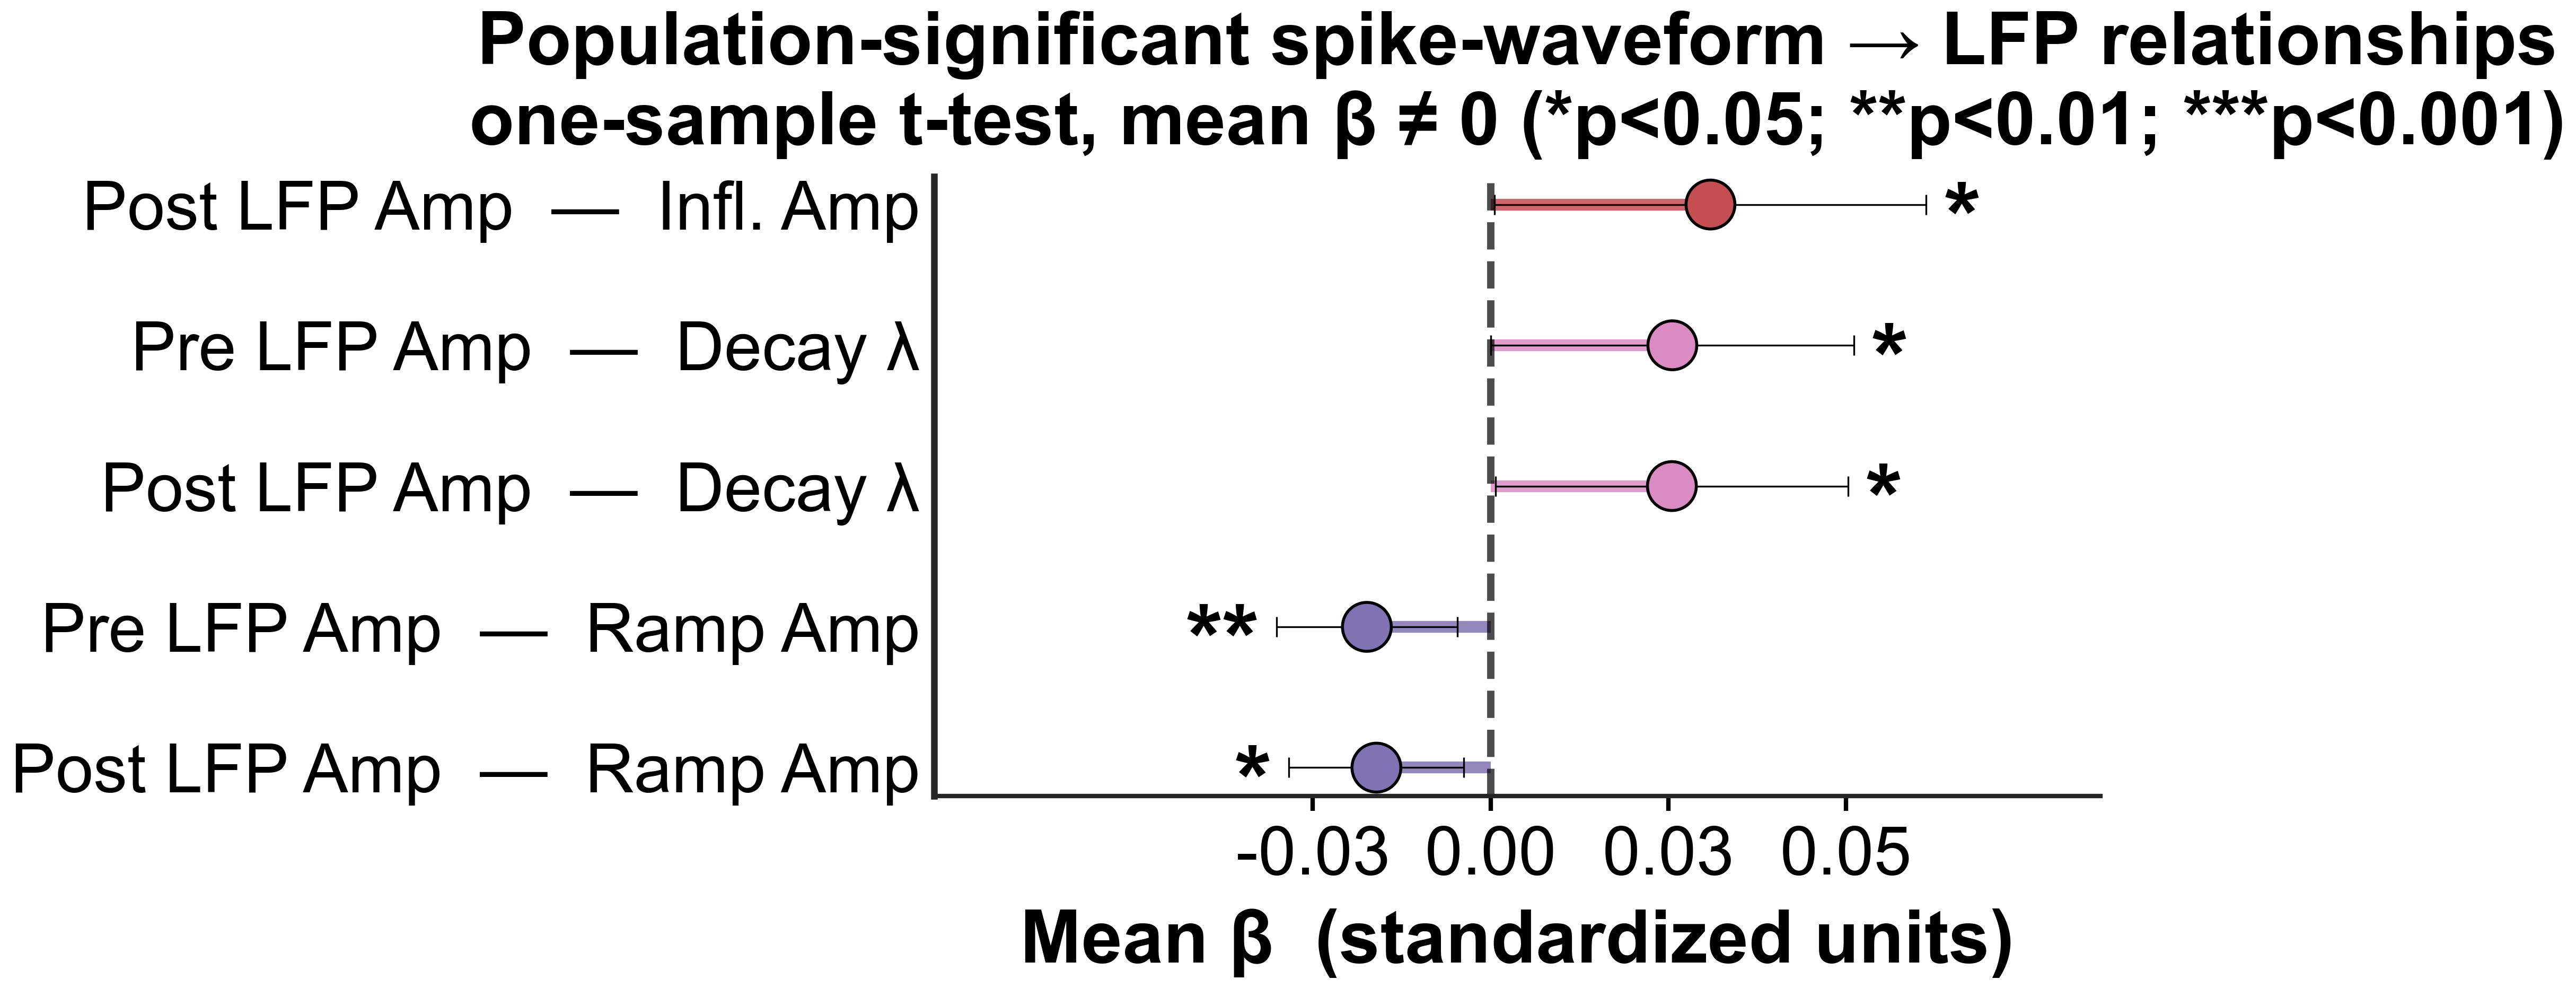

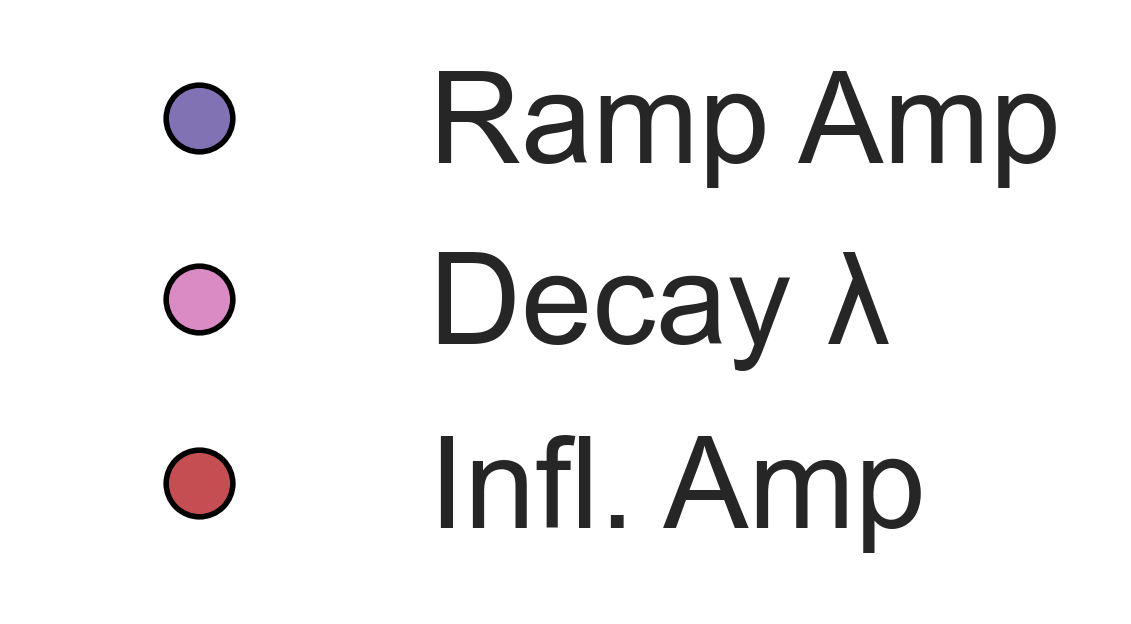

(<Figure size 2200x800 with 1 Axes>,
 <Axes: title={'center': 'Population-significant spike-waveform → LFP relationships\none-sample t-test, mean β ≠ 0 (*p<0.05; **p<0.01; ***p<0.001)'}, xlabel='Mean β  (standardized units)'>)

In [19]:
# ── 4d. Beta — significant relationships, with directionality (cartoony) ─────
import importlib, pop_ridge_utils
importlib.reload(pop_ridge_utils)
from pop_ridge_utils import plot_beta_significant_summary

plot_beta_significant_summary(df_tests, target_names, target_labels)

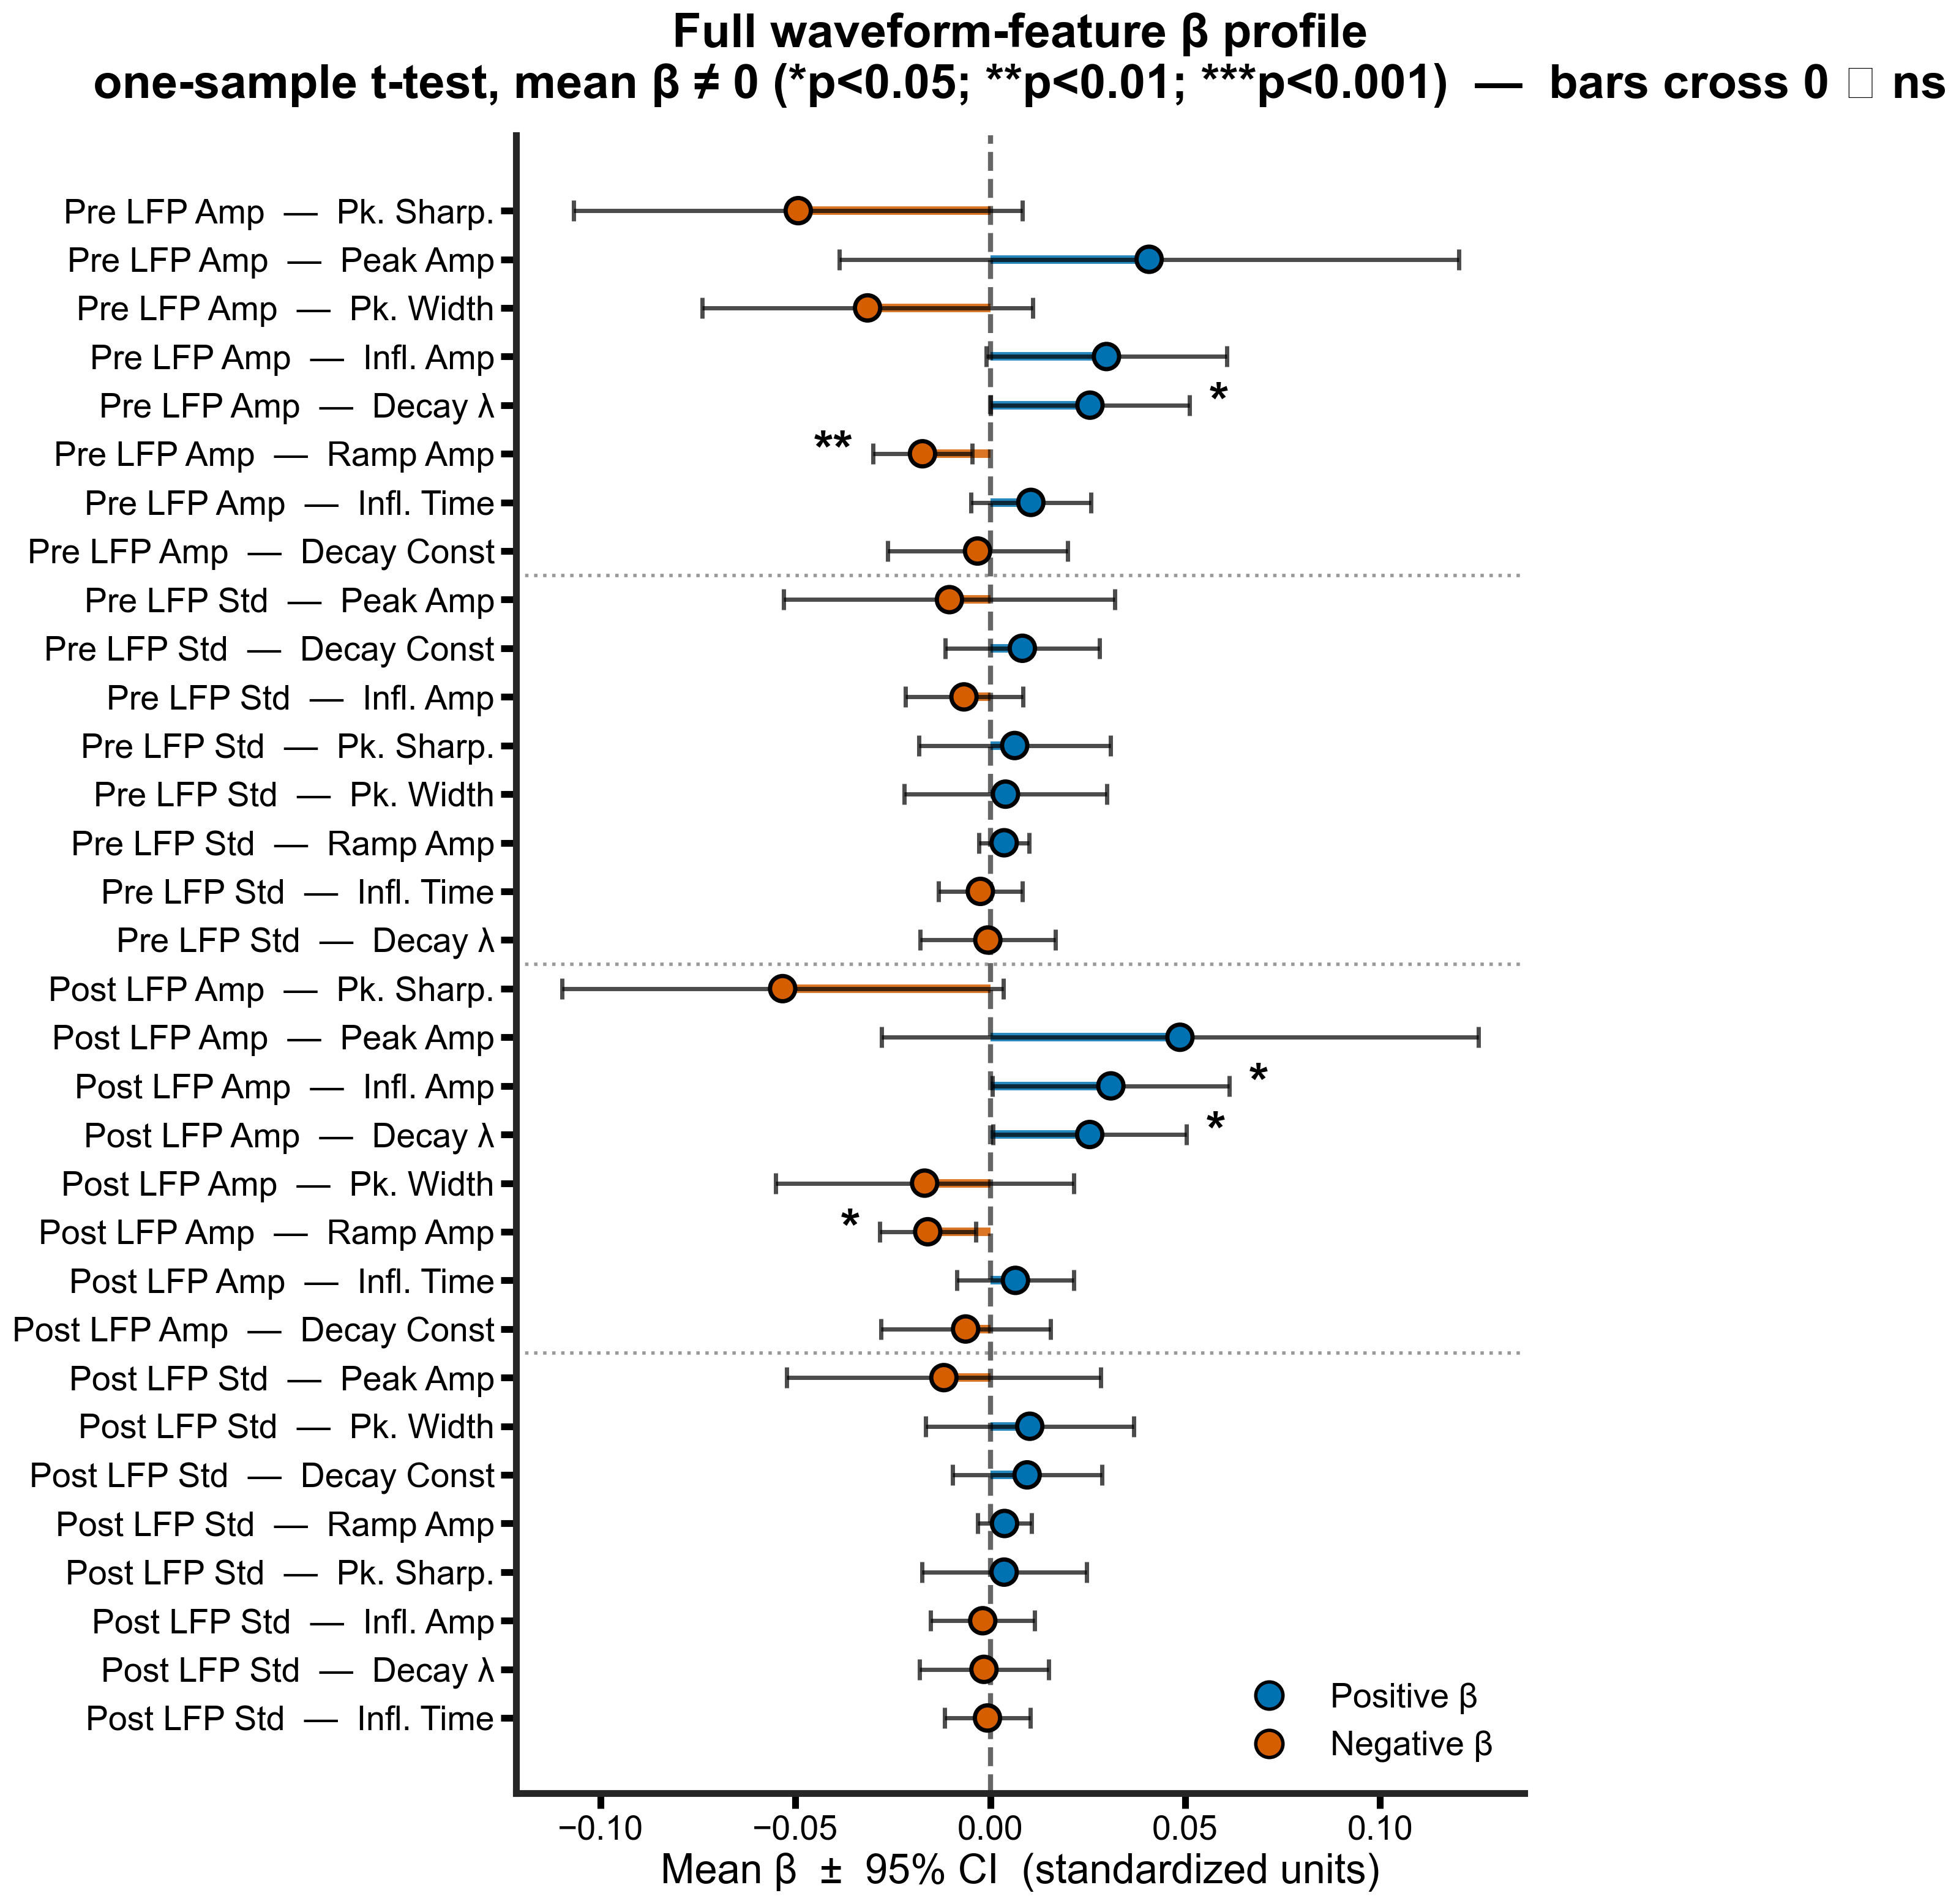

(<Figure size 1300x1600 with 1 Axes>,
 <Axes: title={'center': 'Full waveform-feature β profile\none-sample t-test, mean β ≠ 0 (*p<0.05; **p<0.01; ***p<0.001)  —  bars cross 0 ⟺ ns'}, xlabel='Mean β  ±  95% CI  (standardized units)'>)

In [20]:
# ── 4d-ii. Beta — full profile (all 8 features) for Pre/Post LFP Amp & Std ────
from pop_ridge_utils import plot_beta_full_summary

plot_beta_full_summary(df_tests, target_names, target_labels)

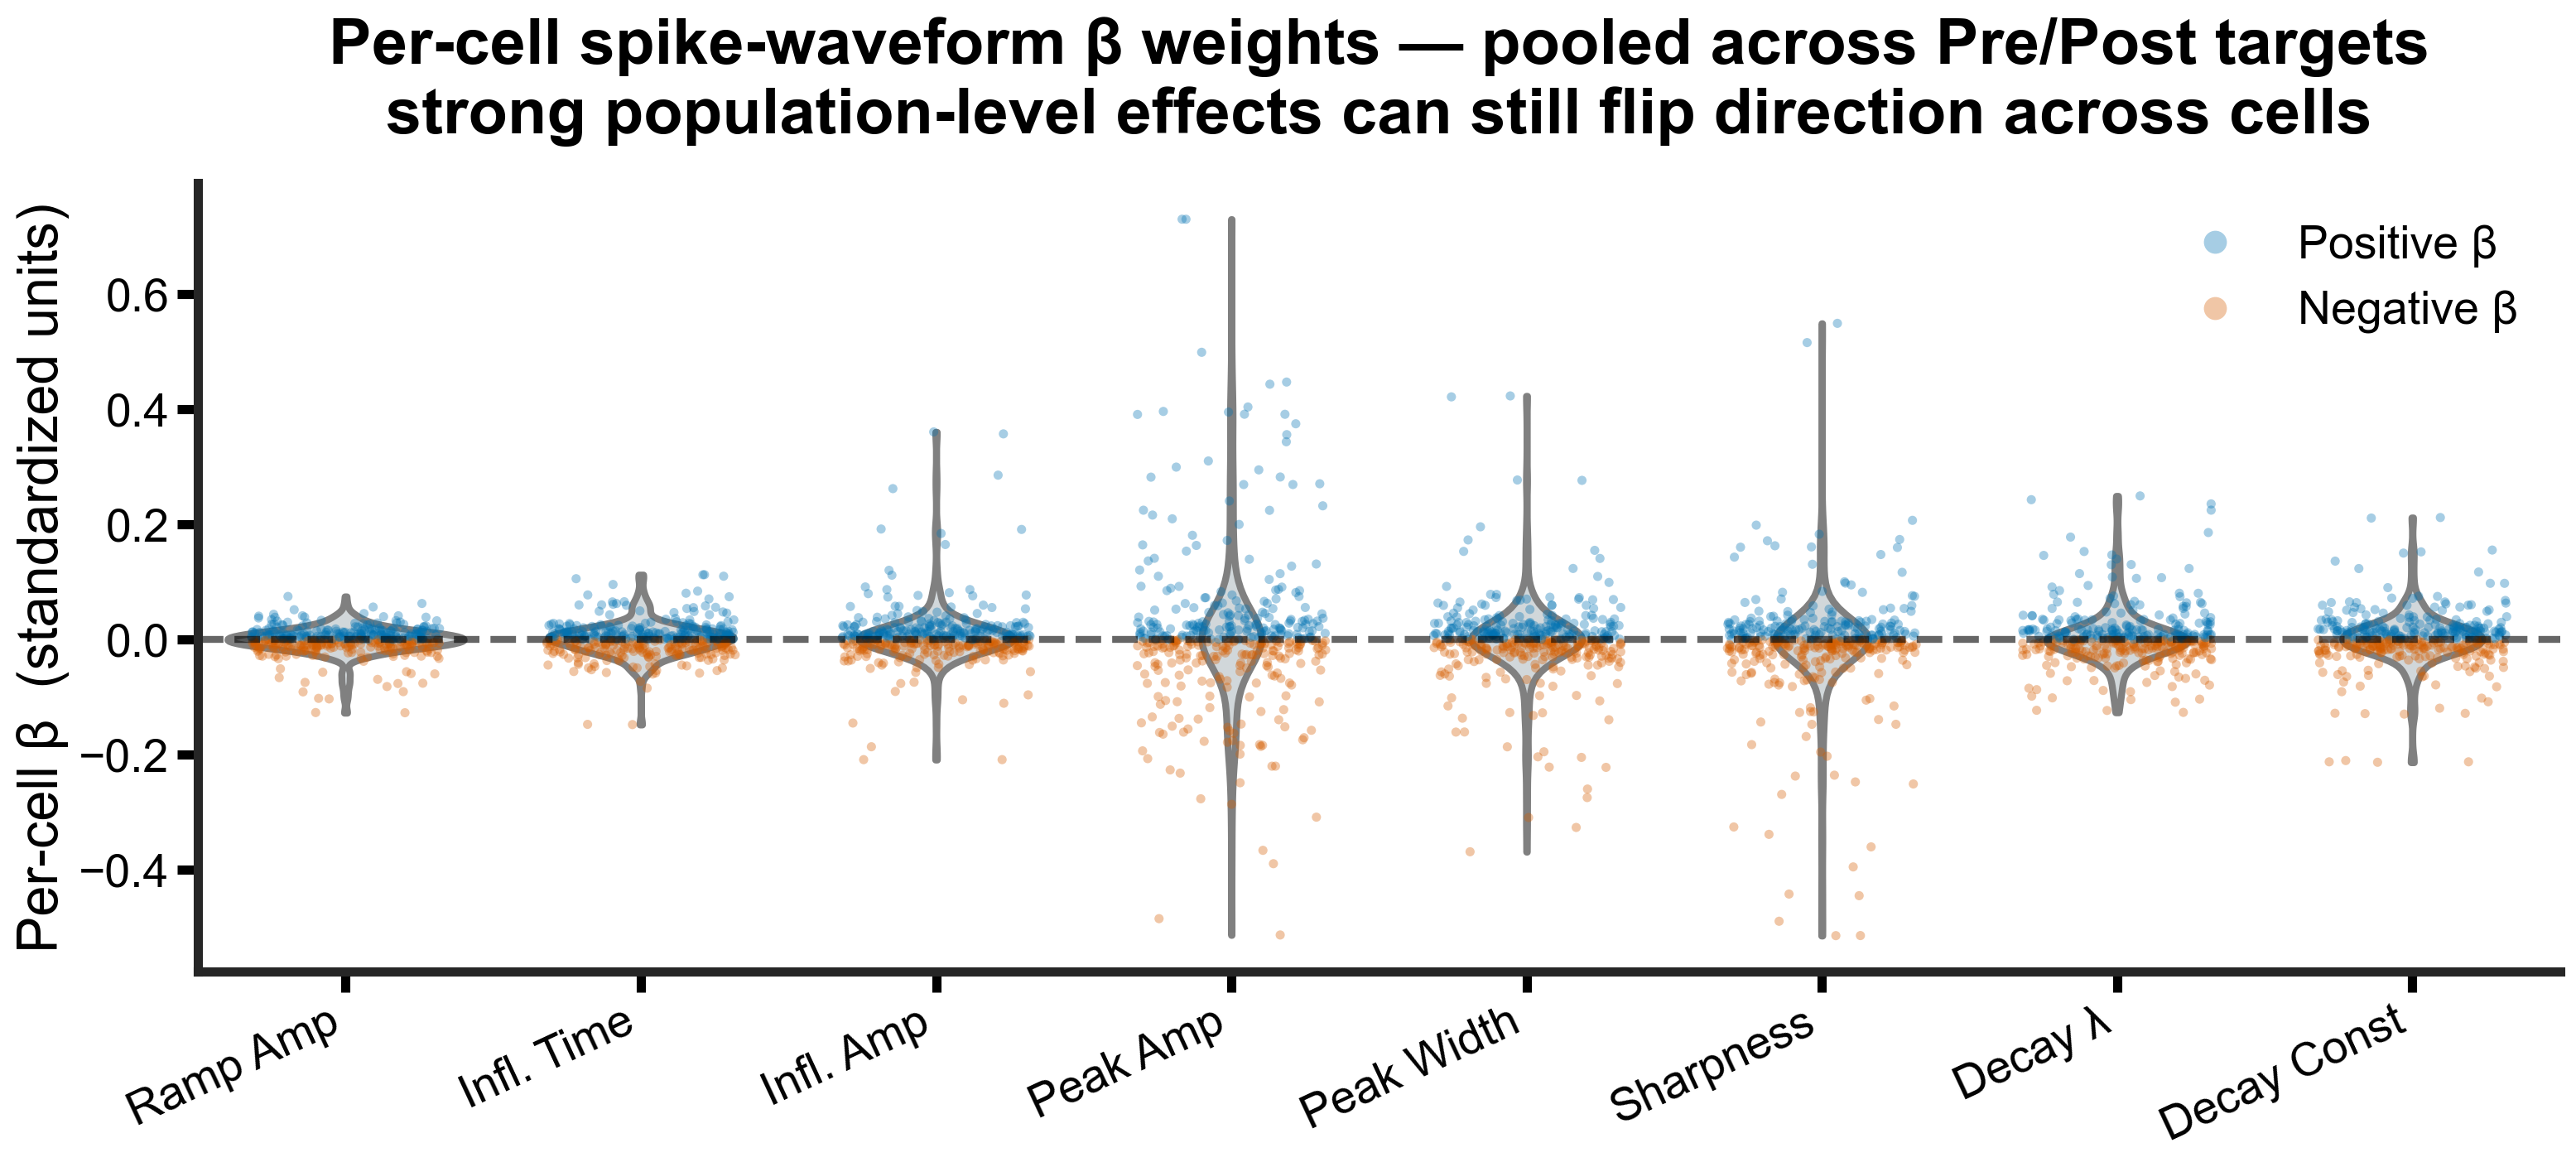

(<Figure size 1600x750 with 1 Axes>,
 <Axes: title={'center': 'Per-cell spike-waveform β weights — pooled across Pre/Post targets\nstrong population-level effects can still flip direction across cells'}, ylabel='Per-cell β  (standardized units)'>)

In [21]:
# ── 4e. Beta — per-cell heterogeneity across all waveform features (cartoony) ─
from pop_ridge_utils import plot_beta_heterogeneity

plot_beta_heterogeneity(beta_pop, target_names, target_labels)

## 5. Actual vs predicted scatter (pooled)

Each point = one spike from one cell, z-scored within cell before pooling.
Only cells with significant Waveform-only models (raw p < 0.05) included. Each colour = one cell.

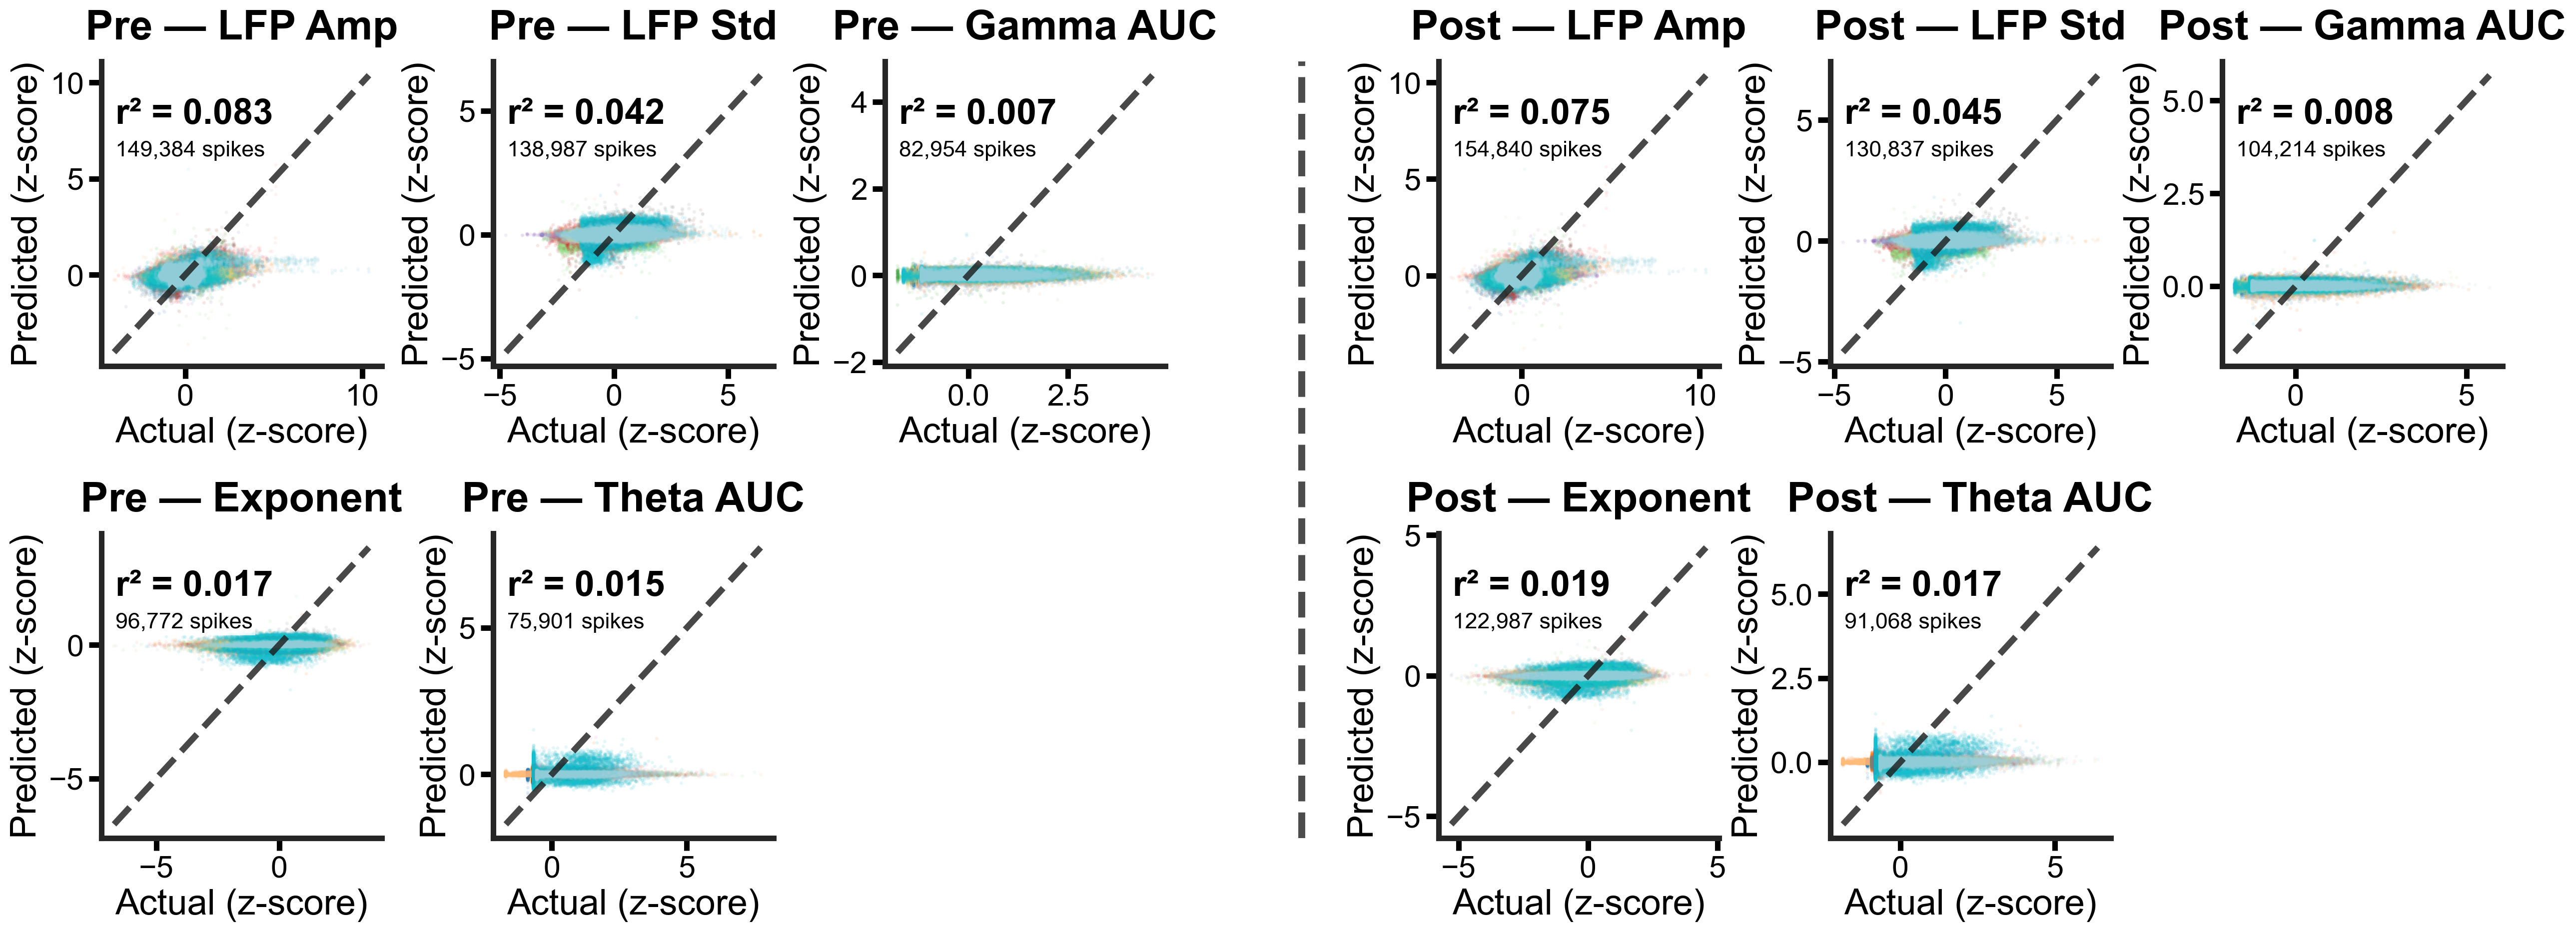

In [22]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [23]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
    df_frac=df_frac, df_r2=df_r2,
)

Saved: population_ridge_results.pkl
     target_label     feature  n  median_beta  p_wilcox    p_val
      Pre LFP Amp    Ramp Amp 39    -0.004564  0.026804 0.008567
      Pre LFP Amp   Infl. Amp 39     0.015600  0.045909 0.057637
      Pre LFP Amp   Sharpness 39    -0.013101  0.039961 0.091254
Pre LFP Amp (HPF)   Infl. Amp 39     0.013003  0.009763 0.020946
     Post LFP Amp    Ramp Amp 39    -0.006101  0.037235 0.011959
     Post LFP Amp   Infl. Amp 39     0.009861  0.035930 0.045956
     Post LFP Amp   Sharpness 39    -0.017221  0.017501 0.064562
     Post LFP Std Decay Const 39     0.018190  0.039961 0.325855
